# Early CVD Prediction - ML Lab Notebook

This notebook presents the final machine-learning workflow for the **Early CVD Prediction** project. It connects the dataset audit, leakage controls, model comparison, ablation/sensitivity studies, explainability, and localhost application into one reproducible project notebook.

Notebook structure:

1. Abstract and project framing
2. Proposal alignment
3. Original notebook audit summary
4. Data audit and dataset discrepancy analysis
5. Methodology
6. Experimentation
7. Results and discussion
8. Ablation / comparative studies
9. Explainability and local prediction
10. Localhost application and project architecture
11. Conclusion and future work

Important caution: this is a public-dataset research prototype. It is **not** a clinical diagnostic device.


## Abstract

Cardiovascular disease prediction is a common applied machine-learning task, but public benchmark studies can overstate results when duplicate rows, preprocessing leakage, test-set tuning, and calibration are not handled correctly. This project converts an exploratory neural-network notebook into a reproducible heart disease prediction system using a clean Python package, leakage-safe pipelines, site-aware validation, explainability, and a localhost FastAPI app.

The primary dataset is `heart_disease_uci.csv`, which contains 920 records from four centers. The binary target is defined as heart disease absent for `num = 0` and present for `num > 0`. The secondary dataset `heart.csv` is used only as a supplementary benchmark after duplicate analysis. Candidate models include penalized logistic regression, random forest, gradient boosting, calibrated gradient boosting, and an MLP baseline based on the original notebook. Penalized logistic regression is selected as the final model because it provides the best balance of calibration, interpretability, and site-aware validation performance.


In [1]:
from pathlib import Path
import json
import os
import sys

import pandas as pd
from IPython.display import Image, Markdown, display

# Find the repository root whether this notebook is run from the root or notebooks/.
PROJECT_ROOT = Path.cwd().resolve()
for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (candidate / "pyproject.toml").exists() and (candidate / "src").exists():
        PROJECT_ROOT = candidate
        break

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from domain.feature_dictionary import FEATURE_COLUMNS, GROUP_COLUMN, TARGET_BINARY, TARGET_MULTICLASS
from domain.risk import risk_category, risk_message
from evaluation.explain import local_explanation
from infrastructure.config import load_config
from infrastructure.data import load_primary_dataset, load_secondary_dataset
from infrastructure.persistence import load_bundle

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

config = load_config("configs/default.yaml")
DATA_DIR = PROJECT_ROOT / "data" / "raw"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIG_DIR = REPORTS_DIR / "figures"
TABLE_DIR = REPORTS_DIR / "tables"
DOCS_DIR = PROJECT_ROOT / "docs"
MODEL_BUNDLE = PROJECT_ROOT / config["paths"]["model_bundle"]

print(f"Project root: {PROJECT_ROOT}")
print(f"Project name: {config['project_name']}")
print(f"Configured model bundle: {MODEL_BUNDLE}")


Project root: C:\Users\mahmu\OneDrive\Documents\New project
Project name: Early CVD Prediction
Configured model bundle: C:\Users\mahmu\OneDrive\Documents\New project\artifacts\model_bundle.joblib


## Proposal Alignment

The proposal title was **An Explainable Deep Learning Framework for Early Prediction of Cardiovascular Disease Using Clinical Data**. The final project keeps the main research direction:

- early CVD / heart disease prediction from clinical variables,
- a deep neural-network baseline,
- comparison with classical machine-learning models,
- explainable model output for global and individual-level interpretation,
- robustness checks for missing values, duplicates, overfitting, and class balance,
- a user-facing decision-support style interface.

The main implementation change is the dataset. The proposal mentioned the Framingham dataset, but the final project uses the provided `heart_disease_uci.csv` and `heart.csv` files. This choice is scientifically justified because the UCI-style file contains hospital/center identifiers, which allows site-aware internal-external validation. The final claims are therefore limited to this public benchmark setting.


## Original Notebook Audit Summary

The exploratory neural-network notebook was audited before building the final package. The reusable parts were kept: clinical feature list, one-hot encoding idea, neural-network baseline, and metric reporting. The fragile parts were replaced by package code.

Main limitations of the exploratory notebook:

- it used a local 303-row `heart.csv` file rather than the currently supplied 1,025-row `heart.csv`,
- the supplied `heart.csv` contains extensive exact duplicates,
- neural-network tuning used the test set as validation data,
- the main evaluation was a single random split,
- preprocessing and artifact generation were dependent on notebook state.

The final project keeps the neural-network idea as `mlp_notebook_baseline`, but the reported results come from the reproducible pipeline in `src/`.


In [2]:
critical_files = [
    DATA_DIR / "heart_disease_uci.csv",
    DATA_DIR / "heart.csv",
    DOCS_DIR / "current_work_audit.md",
    DOCS_DIR / "data_audit_report.md",
    DOCS_DIR / "leakage_audit_report.md",
    REPORTS_DIR / "manuscript" / "early_cvd_ieee_lab_report.docx",
    REPORTS_DIR / "model_card.md",
    MODEL_BUNDLE,
]

artifact_status = pd.DataFrame(
    {
        "artifact": [str(p.relative_to(PROJECT_ROOT)) for p in critical_files],
        "exists": [p.exists() for p in critical_files],
        "size_kb": [round(p.stat().st_size / 1024, 1) if p.exists() else None for p in critical_files],
    }
)
display(artifact_status)

missing = artifact_status.loc[~artifact_status["exists"], "artifact"].tolist()
if missing:
    raise FileNotFoundError("Missing required project artifacts. Run train_project.bat first: " + ", ".join(missing))


,artifact,exists,size_kb
0,data\raw\heart_disease_uci.csv,True,77.5
1,data\raw\heart.csv,True,37.2
2,docs\current_work_audit.md,True,16.4
3,docs\data_audit_report.md,True,1.9
4,docs\leakage_audit_report.md,True,1.1
5,reports\manuscript\early_cvd_ieee_lab_report.docx,True,2361.7
6,reports\model_card.md,True,1.0
7,artifacts\model_bundle.joblib,True,12.1


## Data Audit and Dataset Discrepancy Analysis

Primary research dataset: `heart_disease_uci.csv`.

Secondary benchmark dataset: `heart.csv`.

Key schema differences handled by the project:

- UCI-style data uses `thalch`; the project standardizes it to `thalach`.
- UCI-style data uses `num`; the project collapses it into binary `target_binary`.
- `heart.csv` uses `target` and numeric-coded categories.
- UCI-style data contains the `dataset` source field; the project standardizes it as `center` and uses it only for validation grouping, not prediction.


In [3]:
primary = load_primary_dataset(DATA_DIR / "heart_disease_uci.csv")
secondary_dedup = load_secondary_dataset(DATA_DIR / "heart.csv", deduplicate=True)
secondary_no_dedup = load_secondary_dataset(DATA_DIR / "heart.csv", deduplicate=False)
secondary_raw = pd.read_csv(DATA_DIR / "heart.csv")

summary = pd.DataFrame(
    [
        {
            "dataset": "heart_disease_uci.csv",
            "role": "primary research dataset",
            "rows": len(primary),
            "columns_after_standardization": primary.shape[1],
            "exact_duplicate_rows": int(primary.duplicated().sum()),
            "centers": primary[GROUP_COLUMN].nunique(),
            "target_absent": int((primary[TARGET_BINARY] == 0).sum()),
            "target_present": int((primary[TARGET_BINARY] == 1).sum()),
        },
        {
            "dataset": "heart.csv",
            "role": "secondary supplementary benchmark",
            "rows": len(secondary_no_dedup),
            "columns_after_standardization": secondary_no_dedup.shape[1],
            "exact_duplicate_rows": int(secondary_raw.duplicated().sum()),
            "centers": secondary_no_dedup[GROUP_COLUMN].nunique(),
            "target_absent": int((secondary_no_dedup[TARGET_BINARY] == 0).sum()),
            "target_present": int((secondary_no_dedup[TARGET_BINARY] == 1).sum()),
        },
        {
            "dataset": "heart.csv after exact deduplication",
            "role": "deduplicated supplementary benchmark",
            "rows": len(secondary_dedup),
            "columns_after_standardization": secondary_dedup.shape[1],
            "exact_duplicate_rows": 0,
            "centers": secondary_dedup[GROUP_COLUMN].nunique(),
            "target_absent": int((secondary_dedup[TARGET_BINARY] == 0).sum()),
            "target_present": int((secondary_dedup[TARGET_BINARY] == 1).sum()),
        },
    ]
)

display(summary)


,dataset,role,rows,columns_after_standardization,exact_duplicate_rows,centers,target_absent,target_present
0,heart_disease_uci.csv,primary research dataset,920,17,0,4,411,509
1,heart.csv,secondary supplementary benchmark,1025,16,723,1,499,526
2,heart.csv after exact deduplication,deduplicated supplementary benchmark,302,16,0,1,138,164


In [4]:
print("Primary class balance by center")
class_by_center = pd.crosstab(primary[GROUP_COLUMN], primary[TARGET_BINARY])
class_by_center = class_by_center.rename(columns={0: "absent", 1: "present"})
class_by_center["total"] = class_by_center.sum(axis=1)
class_by_center["prevalence_present"] = (class_by_center["present"] / class_by_center["total"]).round(3)
display(class_by_center)

print("\nPrimary missingness")
missingness = (
    primary[FEATURE_COLUMNS]
    .isna()
    .sum()
    .rename("missing_n")
    .to_frame()
    .assign(missing_percent=lambda d: (d["missing_n"] / len(primary) * 100).round(2))
    .query("missing_n > 0")
    .sort_values("missing_n", ascending=False)
)
display(missingness)

print("\nMulticlass target feasibility check")
multiclass_counts = primary[TARGET_MULTICLASS].value_counts().sort_index().rename_axis("num").reset_index(name="records")
display(multiclass_counts)


Primary class balance by center


target_binary,absent,present,total,prevalence_present
center,,,,
Cleveland,165,139,304,0.457
Hungary,187,106,293,0.362
Switzerland,8,115,123,0.935
VA Long Beach,51,149,200,0.745



Primary missingness


,missing_n,missing_percent
ca,611,66.41
thal,486,52.83
slope,309,33.59
fbs,90,9.78
oldpeak,62,6.74
trestbps,59,6.41
exang,55,5.98
thalach,55,5.98
chol,30,3.26
restecg,2,0.22



Multiclass target feasibility check


,num,records
0,0,411
1,1,265
2,2,109
3,3,107
4,4,28


**Class Distribution Primary**

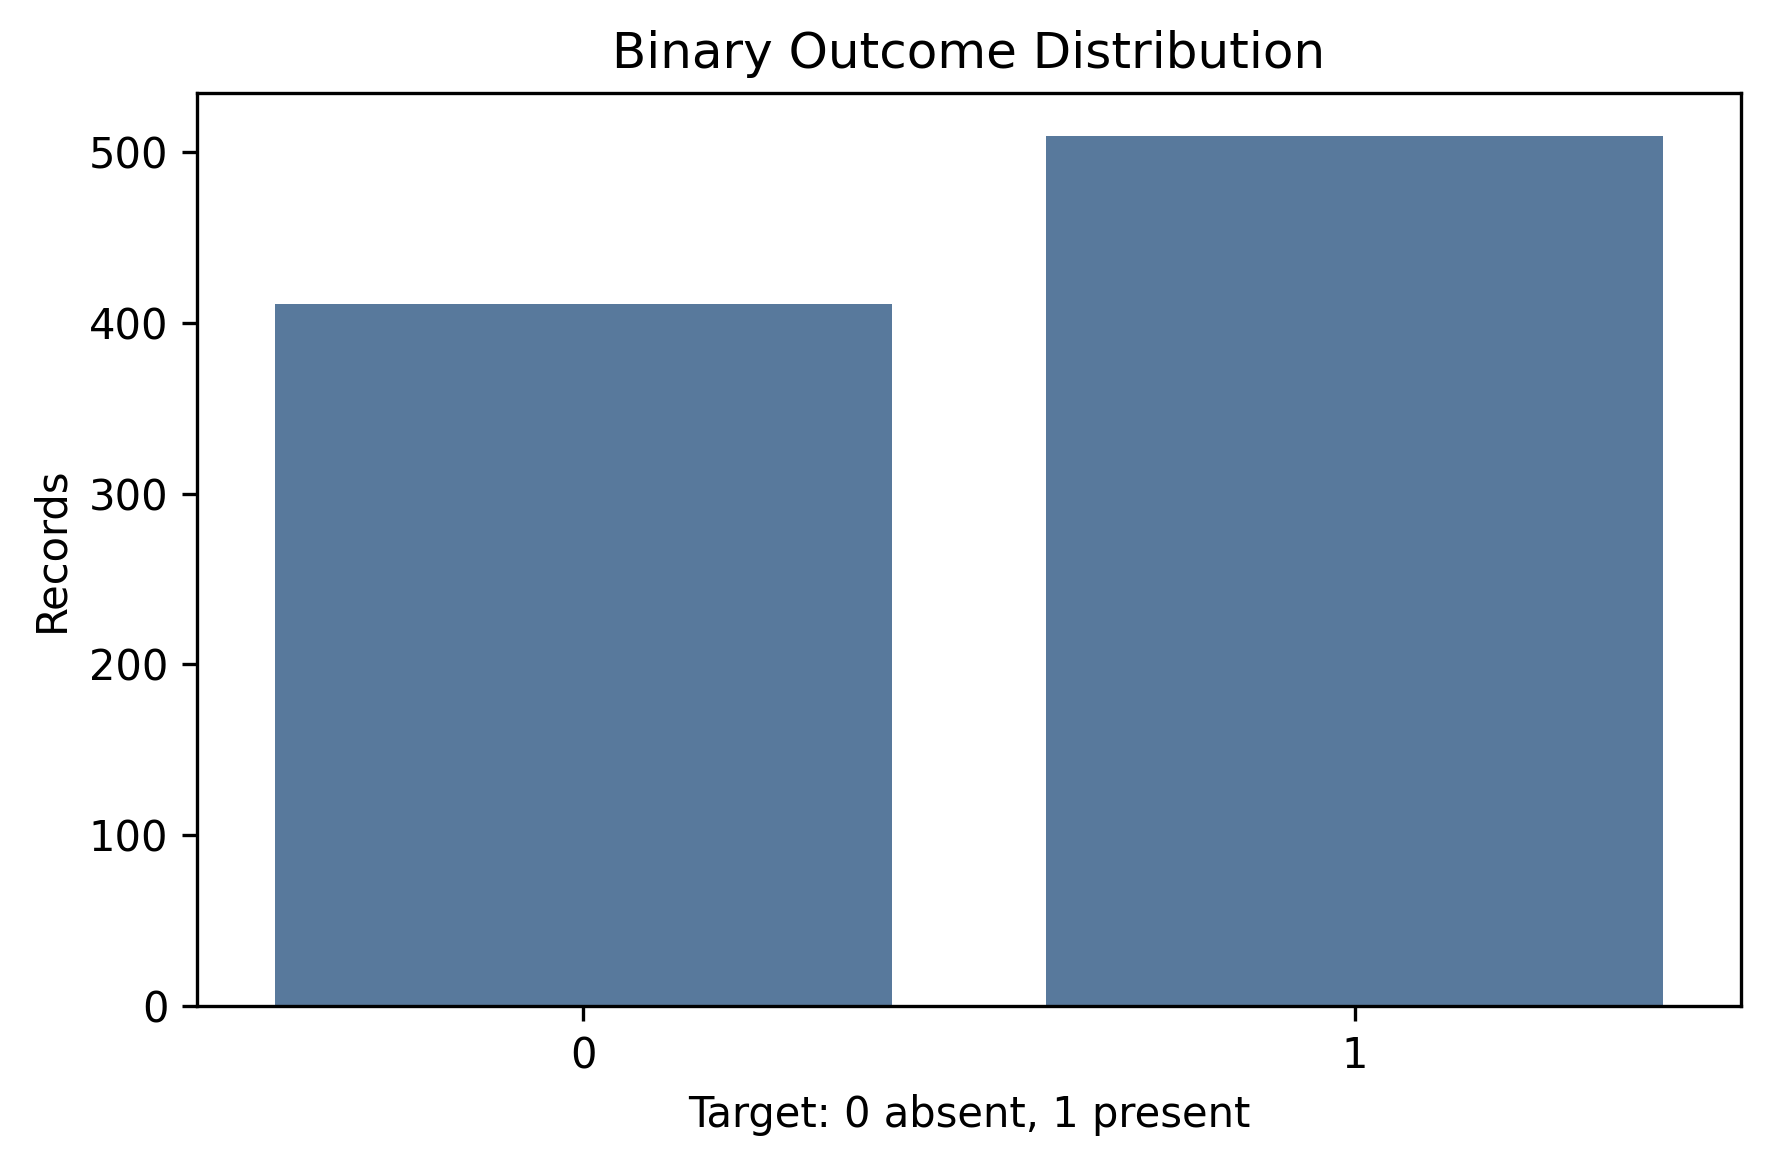

**Site Distribution Primary**

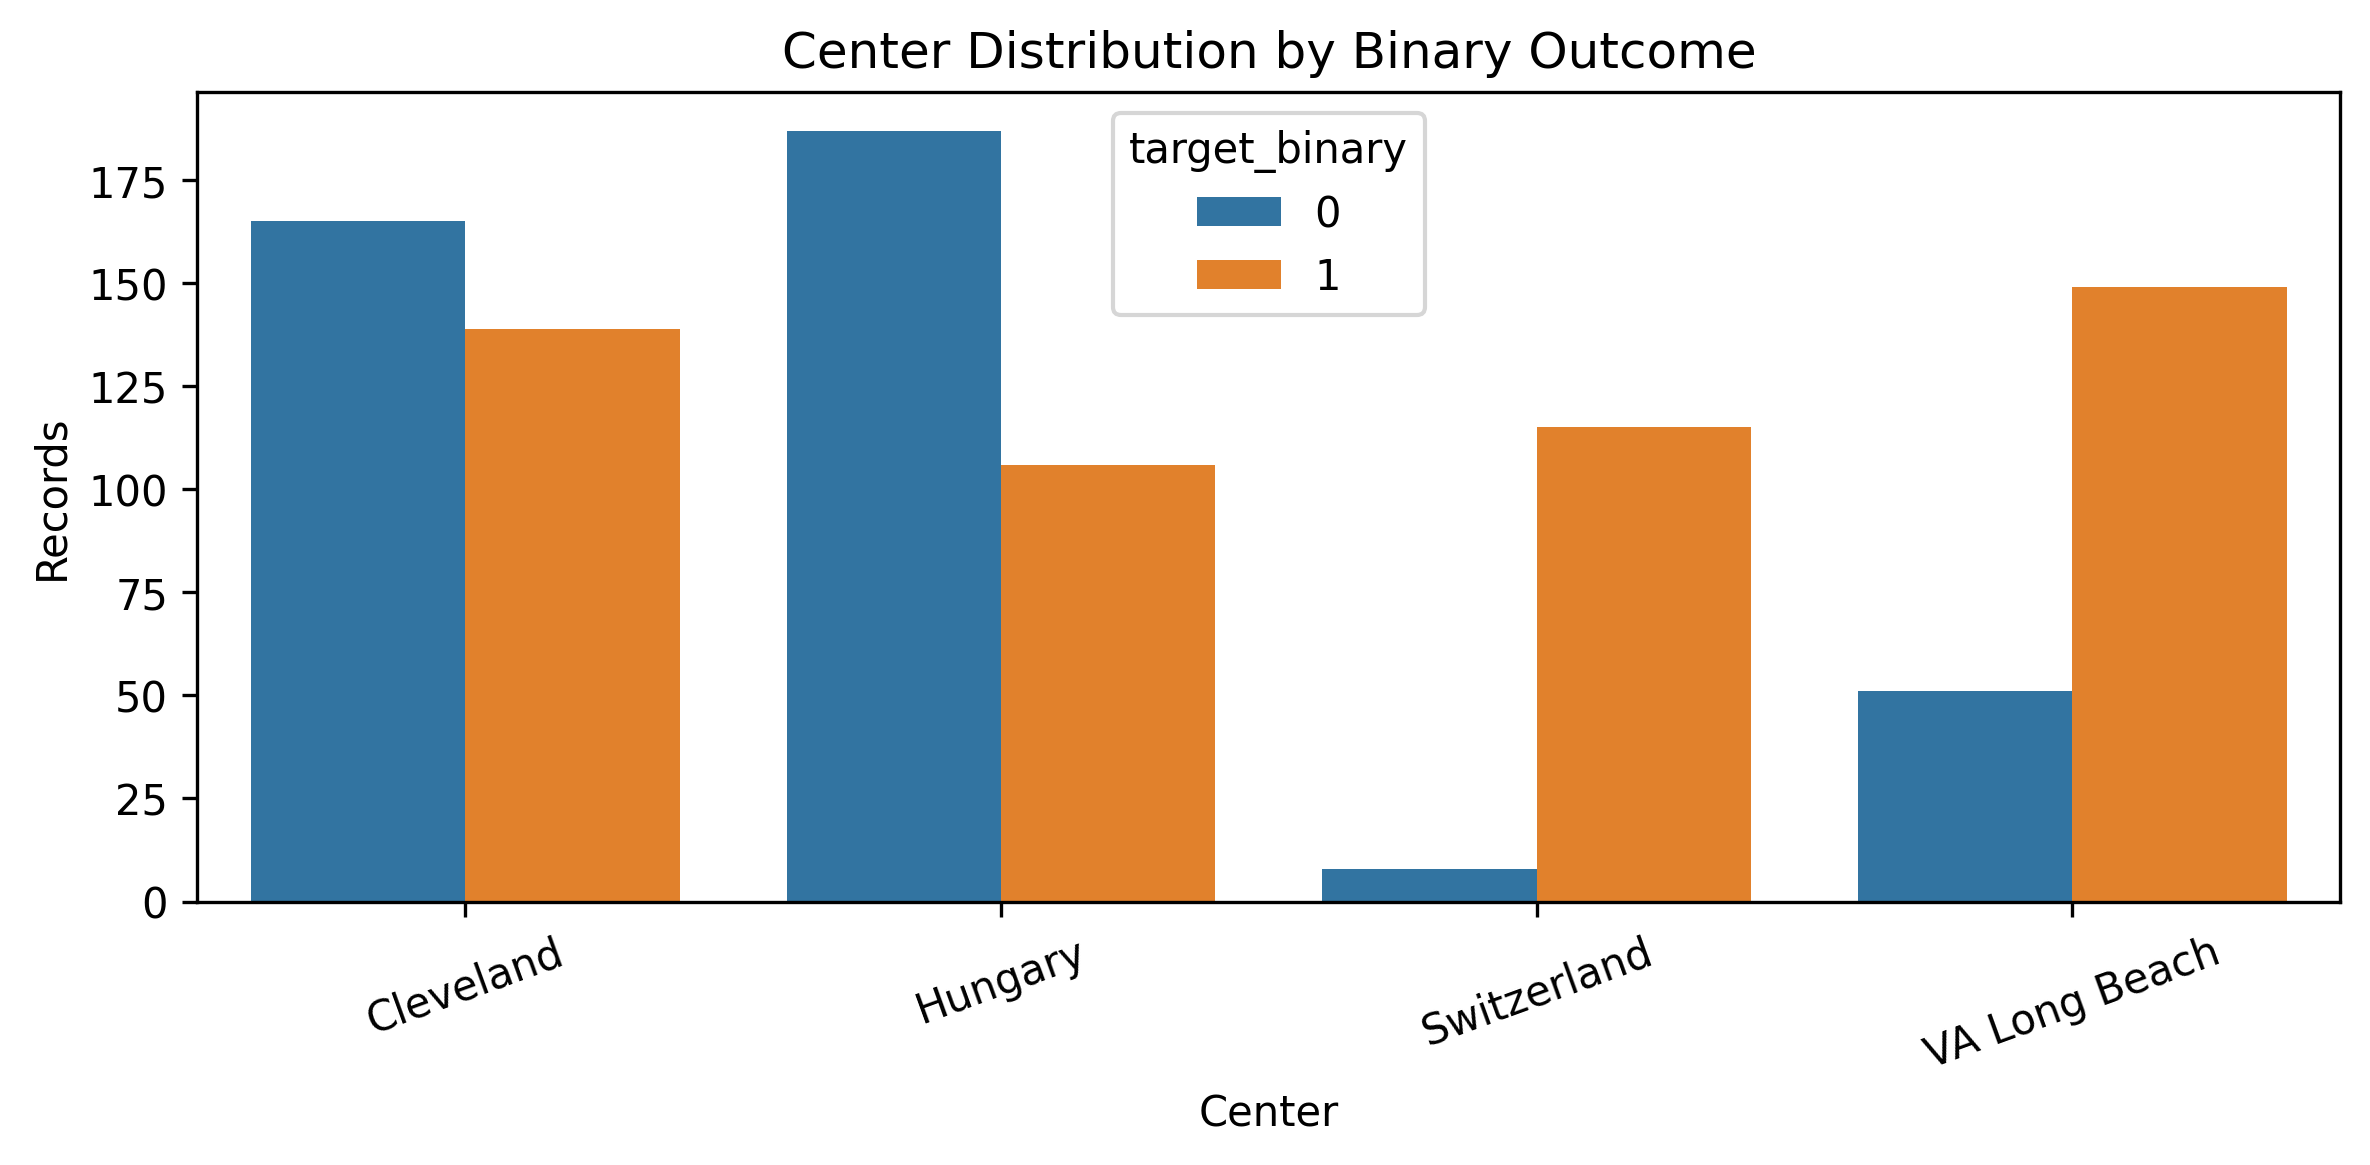

**Missingness Heatmap**

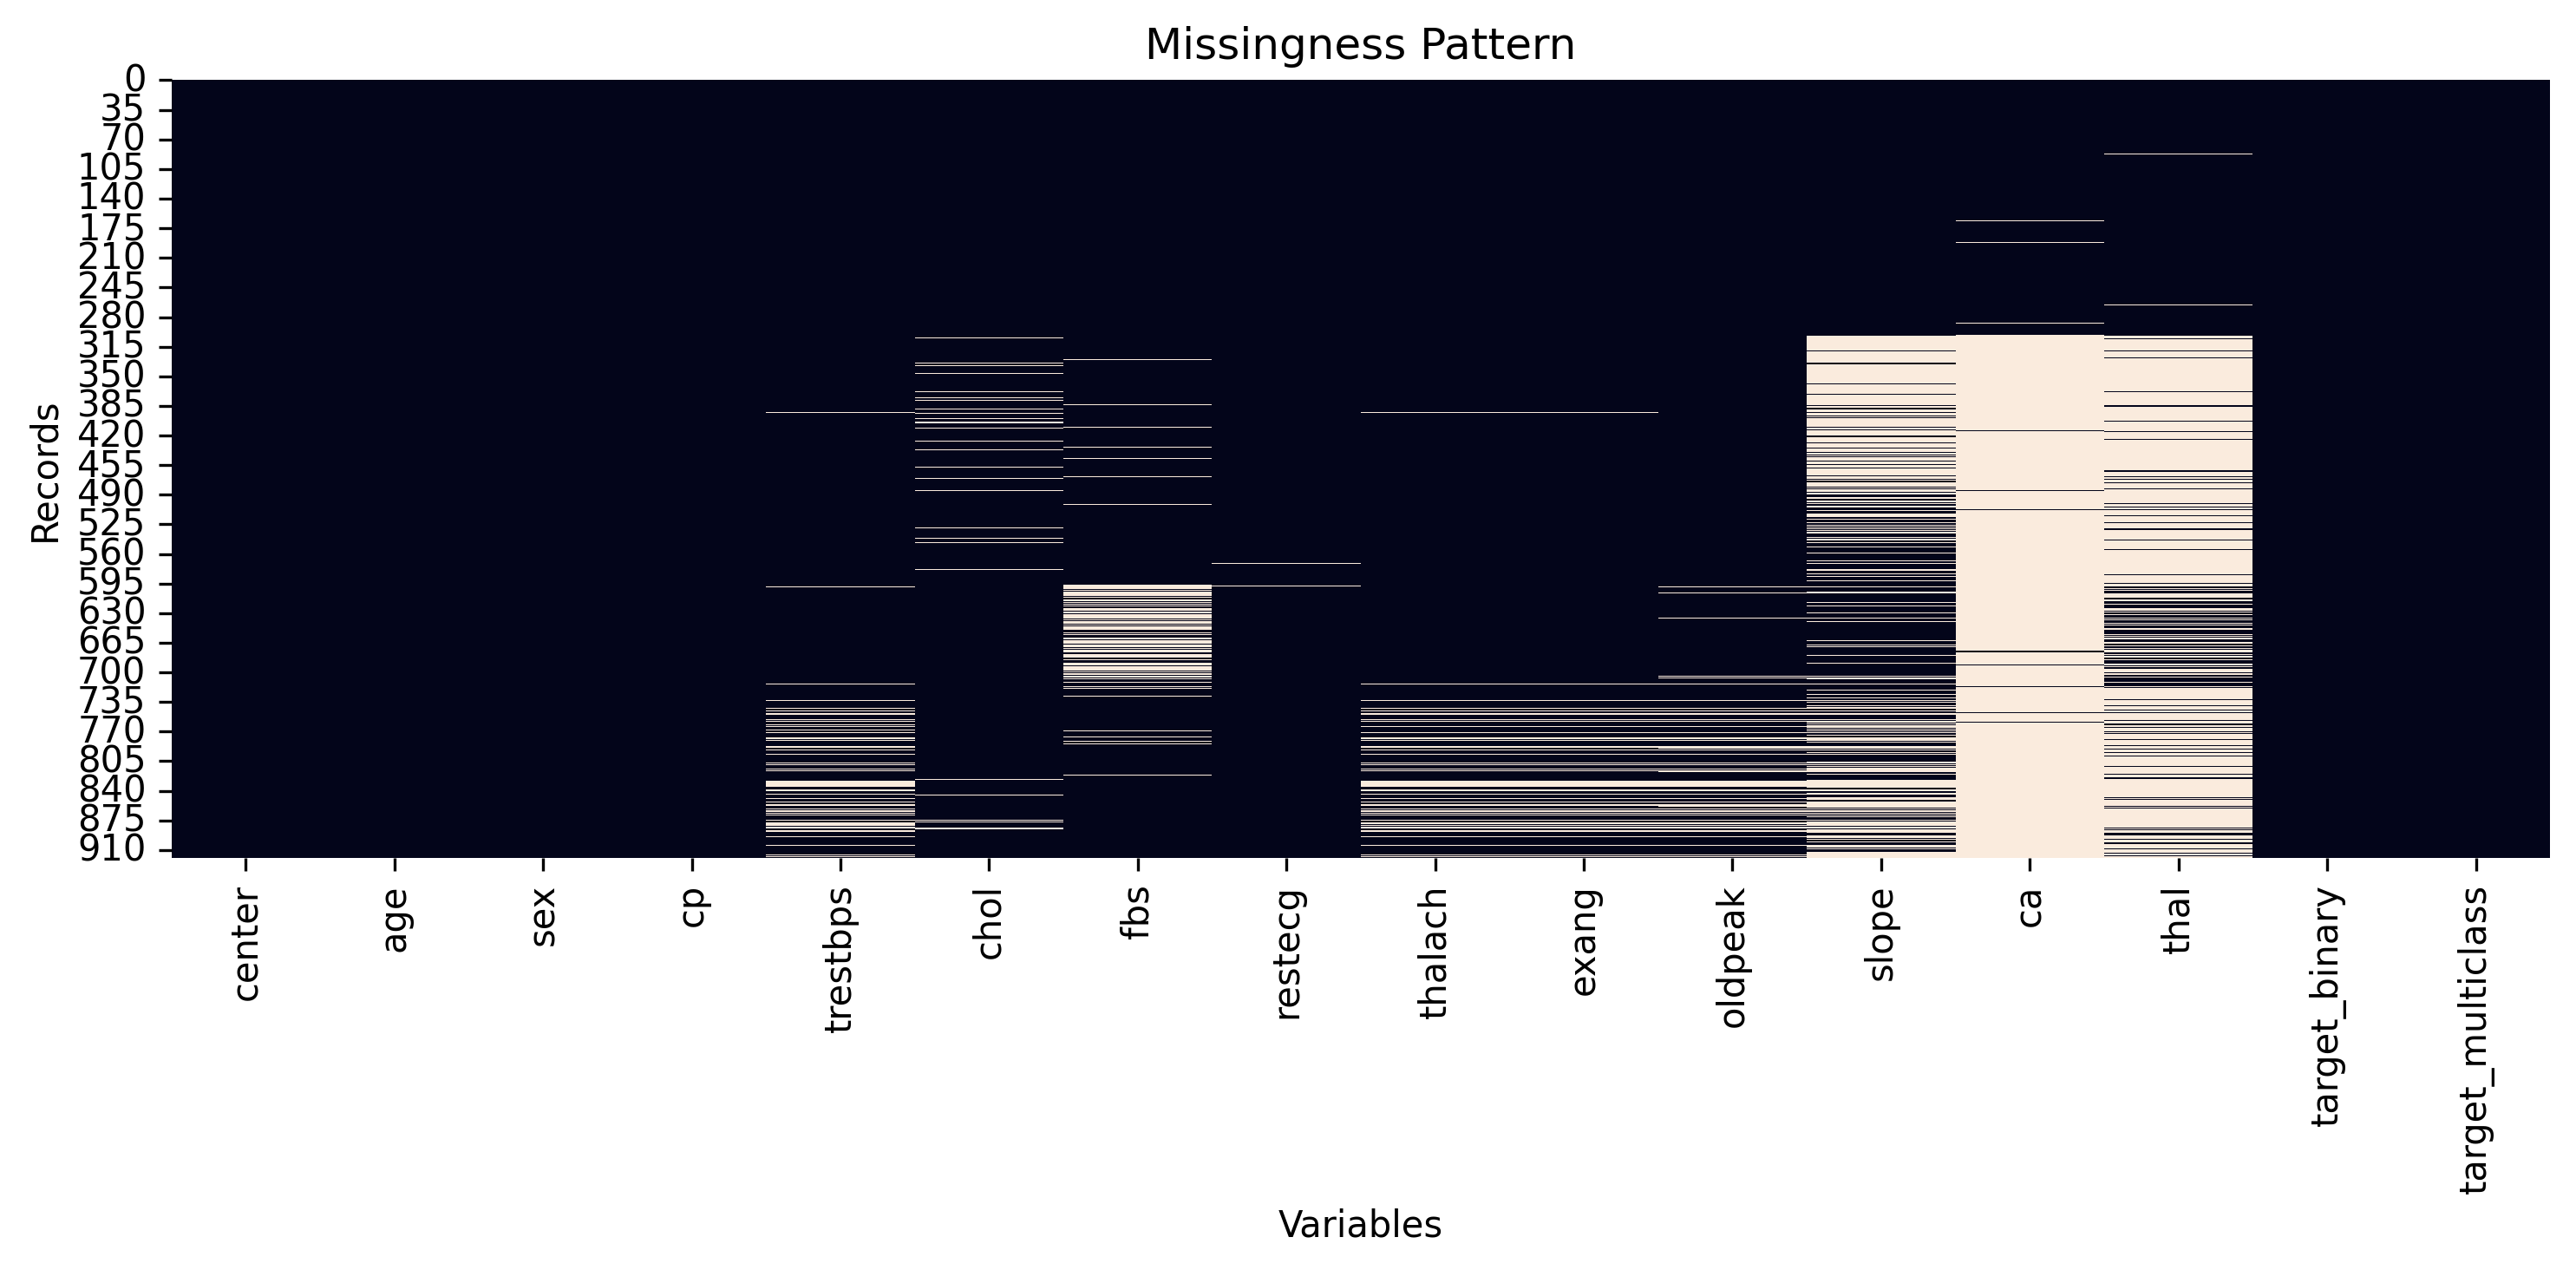

In [5]:
for figure in [
    "class_distribution_primary.png",
    "site_distribution_primary.png",
    "missingness_heatmap.png",
]:
    path = FIG_DIR / figure
    display(Markdown(f"**{figure.replace('_', ' ').replace('.png', '').title()}**"))
    display(Image(filename=str(path)))


## Methodology

The final methodology treats the project as prediction-model research.

Workflow:

`raw data -> audit -> canonical schema -> fold-contained preprocessing -> site-aware validation -> model comparison -> calibration-aware selection -> model bundle -> FastAPI app`

Important design choices:

- The binary target is `target_binary = 1` when UCI `num > 0`, otherwise `0`.
- The center/hospital source is used as a validation group and is excluded from the predictor set.
- Numeric variables are median-imputed and standardized inside scikit-learn pipelines.
- Categorical variables are most-frequent-imputed and one-hot encoded inside the same pipelines.
- The main validation is leave-one-center-out internal-external validation.
- Inner model selection is performed only on the development centers.
- Model choice considers AUROC, AUPRC, Brier score, calibration slope, MCC, stability, and interpretability.

This is stronger than a single random split because it tests whether the model generalizes across hospital-like data sources.


In [6]:
# Optional full retraining cell.
# This can take time. The default path reads already generated reproducible artifacts.
RUN_FULL_TRAINING = False

if RUN_FULL_TRAINING:
    from application.train import train_and_evaluate
    result = train_and_evaluate(config)
    display(result["summary"].head())
else:
    print("Full training skipped. Set RUN_FULL_TRAINING = True to regenerate all tables, figures, and the model bundle.")
    print("Windows shortcut: double-click train_project.bat from the project root.")


Full training skipped. Set RUN_FULL_TRAINING = True to regenerate all tables, figures, and the model bundle.
Windows shortcut: double-click train_project.bat from the project root.


## Experimentation

The project compares five models:

1. Penalized logistic regression
2. Random forest
3. Gradient boosting
4. Calibrated gradient boosting
5. MLP notebook baseline

The neural network is included because it was the original modeling direction. It is treated as a comparator, not assumed to be the best model.


In [7]:
required_tables = [
    "model_selection_ranking",
    "model_comparison",
    "center_metrics",
    "bootstrap_confidence_intervals",
    "threshold_analysis",
    "duplicate_sensitivity",
    "supplementary_heart_csv_benchmark",
    "global_feature_importance",
]

tables = {}
for name in required_tables:
    path = TABLE_DIR / f"{name}.csv"
    if not path.exists():
        raise FileNotFoundError(f"Missing table: {path}. Run train_project.bat first.")
    tables[name] = pd.read_csv(path)

ranked = tables["model_selection_ranking"].sort_values("selection_score")
champion = ranked.iloc[0]["model"]

cols = [
    "model",
    "selection_score",
    "auroc_mean",
    "auprc_mean",
    "brier_mean",
    "balanced_accuracy_mean",
    "mcc_mean",
    "calibration_slope_mean",
]
display(ranked[cols].round(3))
print(f"Selected champion: {champion}")


,model,selection_score,auroc_mean,auprc_mean,brier_mean,balanced_accuracy_mean,mcc_mean,calibration_slope_mean
0,logistic_l2,10.25,0.799,0.880,0.168,0.745,0.441,0.966
1,calibrated_gradient_boosting,12.75,0.809,0.877,0.174,0.714,0.385,1.288
2,random_forest,16.10,0.800,0.873,0.170,0.716,0.387,1.328
3,gradient_boosting,20.00,0.793,0.861,0.180,0.732,0.410,1.336
4,mlp_notebook_baseline,30.50,0.779,0.858,0.187,0.678,0.342,1.940


Selected champion: logistic_l2


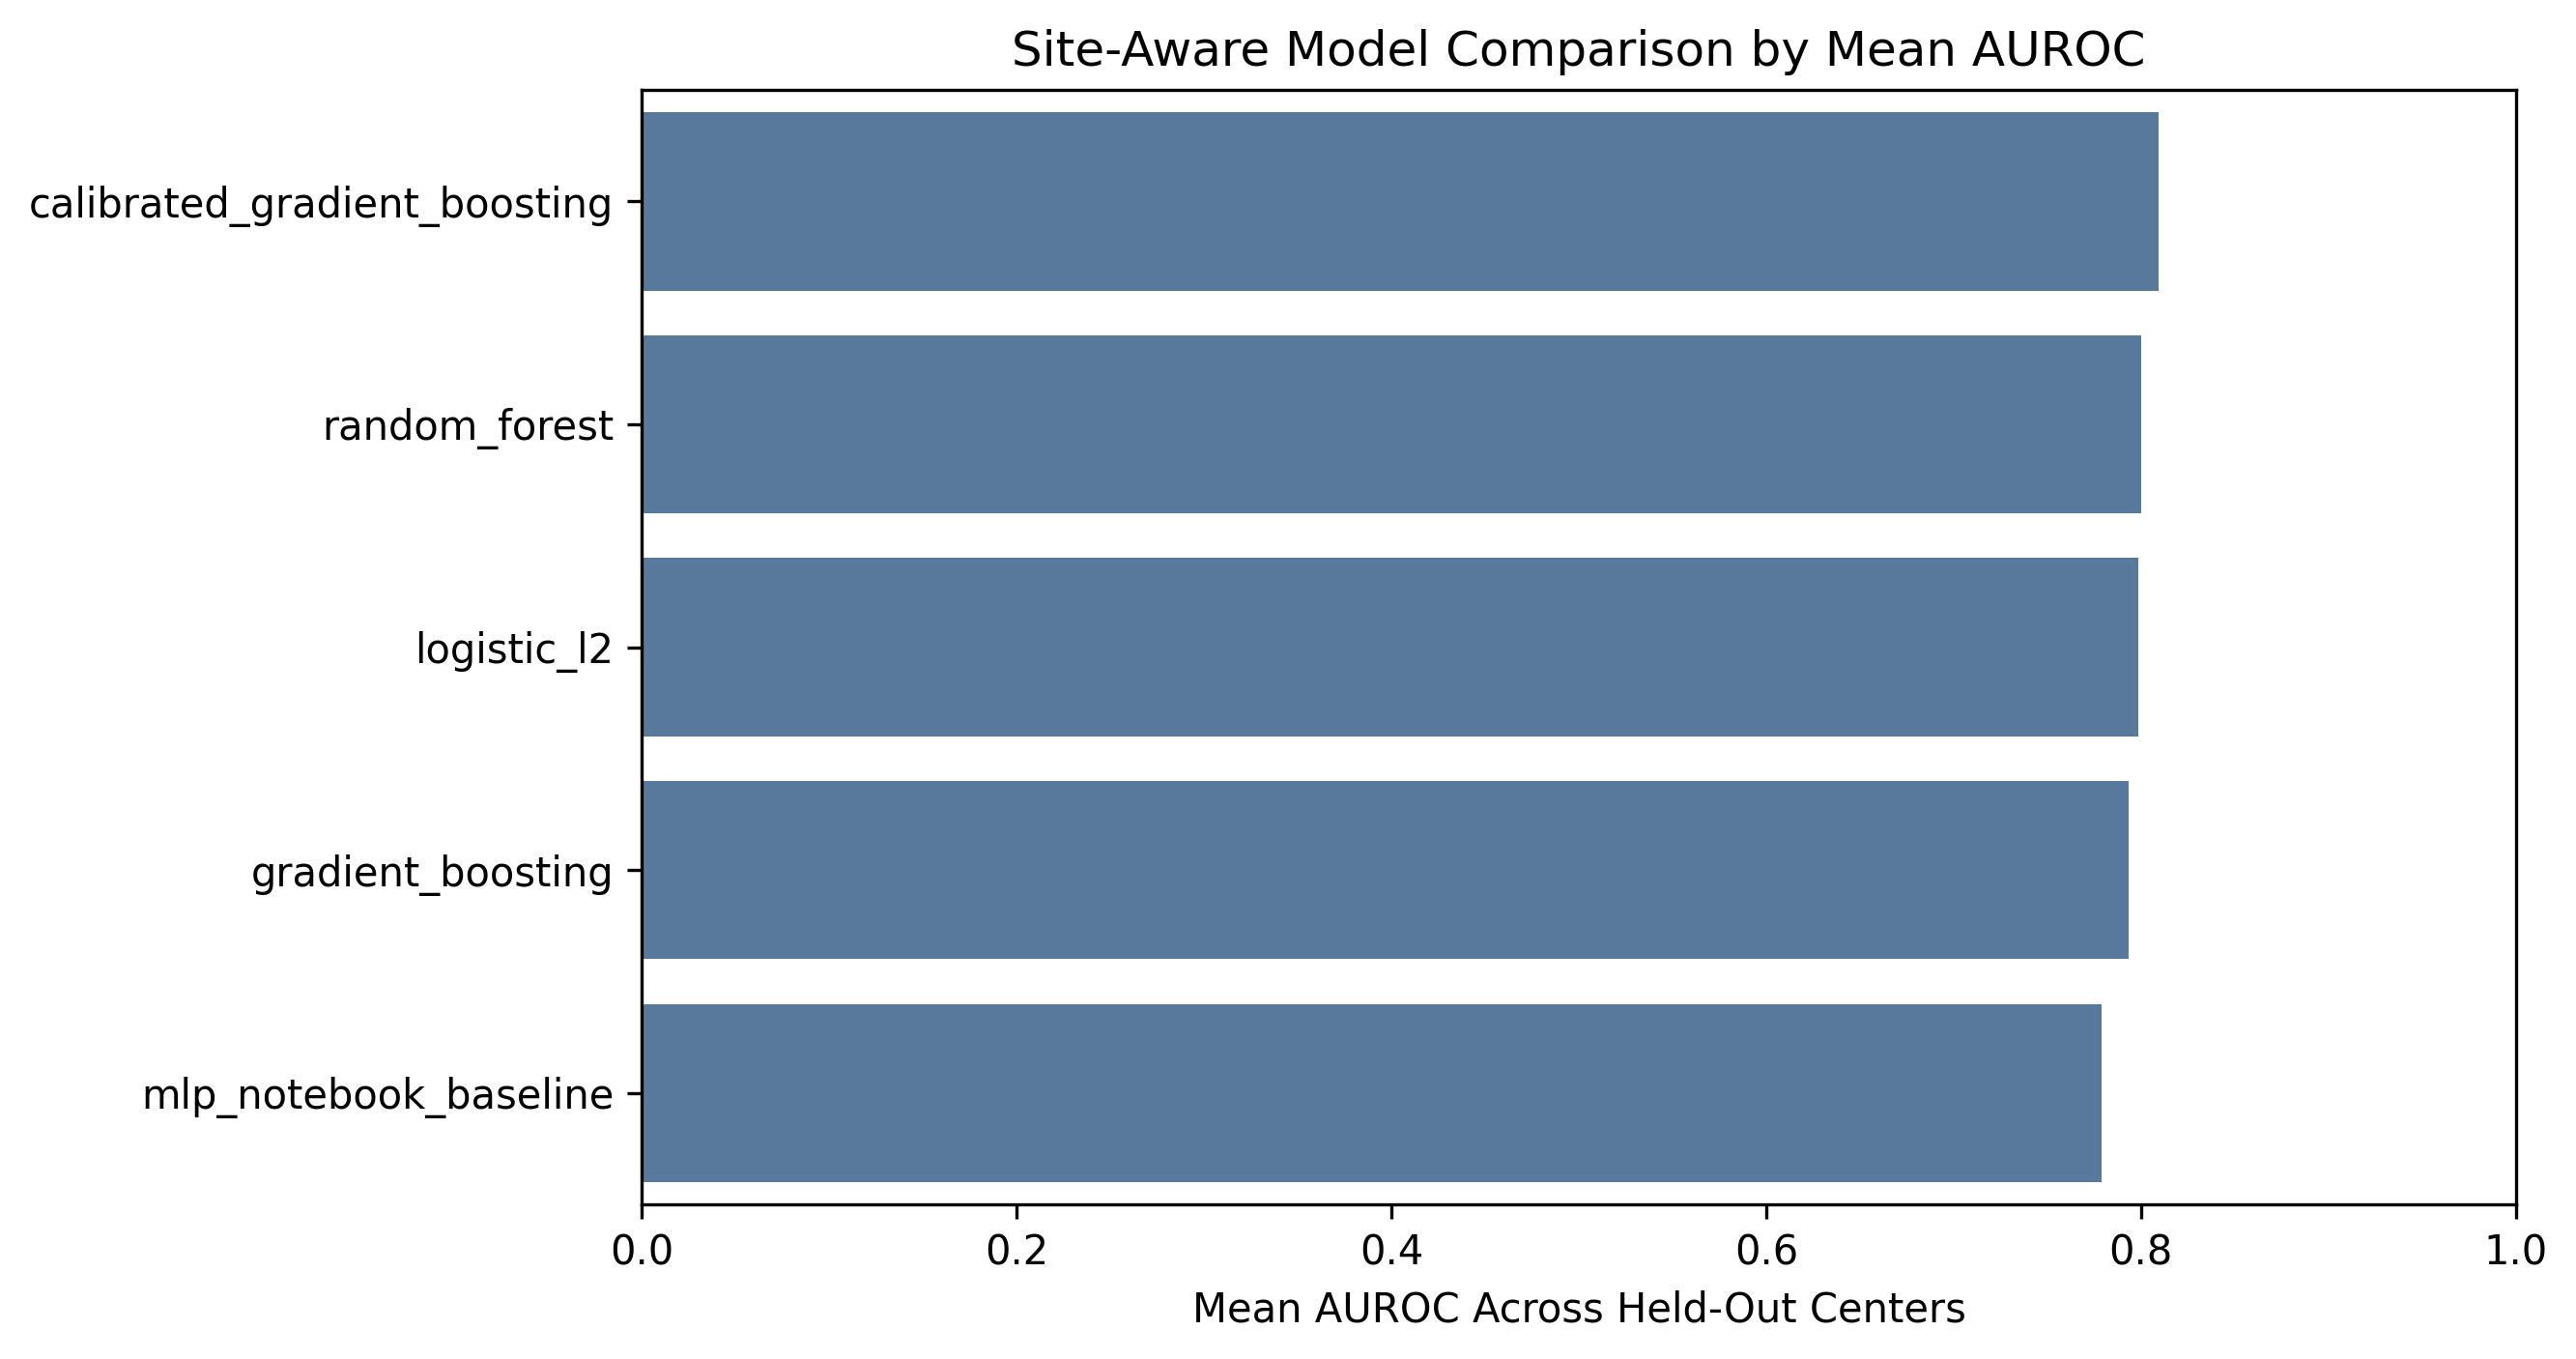

In [8]:
display(Image(filename=str(FIG_DIR / "model_comparison.png")))


## Results and Discussion

The selected final model is **penalized logistic regression**. Calibrated gradient boosting had slightly higher mean AUROC, but logistic regression was selected because it had the best overall selection score after considering calibration, Brier score, MCC, stability, and interpretability.

This is an important scientific point: a more complex model is not automatically better for a small, center-shifted clinical benchmark dataset.


In [9]:
center = tables["center_metrics"].query("model == @champion").copy()
center_view = center[
    [
        "held_out_center",
        "auroc",
        "auprc",
        "brier",
        "balanced_accuracy",
        "sensitivity",
        "specificity",
        "mcc",
        "calibration_slope",
        "n",
        "prevalence",
    ]
]
display(center_view.round(3))

print("Center-aware mean and standard deviation for champion")
display(center_view.drop(columns=["held_out_center"]).agg(["mean", "std"]).round(3))


,held_out_center,auroc,auprc,brier,balanced_accuracy,sensitivity,specificity,mcc,calibration_slope,n,prevalence
0,Cleveland,0.867,0.867,0.145,0.802,0.755,0.848,0.608,1.143,304.0,0.457
5,Hungary,0.876,0.828,0.132,0.790,0.660,0.920,0.614,1.372,293.0,0.362
10,Switzerland,0.742,0.972,0.204,0.727,0.704,0.750,0.239,0.804,123.0,0.935
15,VA Long Beach,0.709,0.853,0.189,0.660,0.772,0.549,0.302,0.546,200.0,0.745


Center-aware mean and standard deviation for champion


,auroc,auprc,brier,balanced_accuracy,sensitivity,specificity,mcc,calibration_slope,n,prevalence
mean,0.799,0.880,0.168,0.745,0.723,0.767,0.441,0.966,230.000,0.625
std,0.085,0.064,0.035,0.065,0.051,0.161,0.198,0.364,85.233,0.263


In [10]:
print("Bootstrap confidence intervals for pooled held-out-center predictions")
boot = tables["bootstrap_confidence_intervals"]
display(boot.round(3))

print("Threshold analysis")
threshold_view = tables["threshold_analysis"][[
    "threshold",
    "sensitivity",
    "specificity",
    "precision_ppv",
    "npv",
    "balanced_accuracy",
    "mcc",
]]
display(threshold_view.round(3))


Bootstrap confidence intervals for pooled held-out-center predictions


,metric,estimate,ci_lower,ci_upper,bootstrap_iterations
0,auroc,0.855,0.828,0.878,200
1,auprc,0.864,0.825,0.893,200
2,balanced_accuracy,0.785,0.756,0.811,200
3,brier,0.159,0.145,0.173,200
4,sensitivity,0.729,0.690,0.766,200
5,specificity,0.842,0.804,0.875,200


Threshold analysis


,threshold,sensitivity,specificity,precision_ppv,npv,balanced_accuracy,mcc
0,0.1,0.988,0.214,0.609,0.936,0.601,0.332
1,0.2,0.931,0.472,0.686,0.847,0.702,0.464
2,0.3,0.876,0.637,0.750,0.806,0.757,0.534
3,0.4,0.806,0.752,0.801,0.757,0.779,0.558
4,0.5,0.729,0.842,0.851,0.715,0.785,0.568
5,0.6,0.640,0.888,0.876,0.666,0.764,0.535
6,0.7,0.525,0.925,0.896,0.611,0.725,0.477
7,0.8,0.365,0.964,0.925,0.551,0.664,0.396
8,0.9,0.173,0.990,0.957,0.492,0.582,0.270


**Roc Curves**

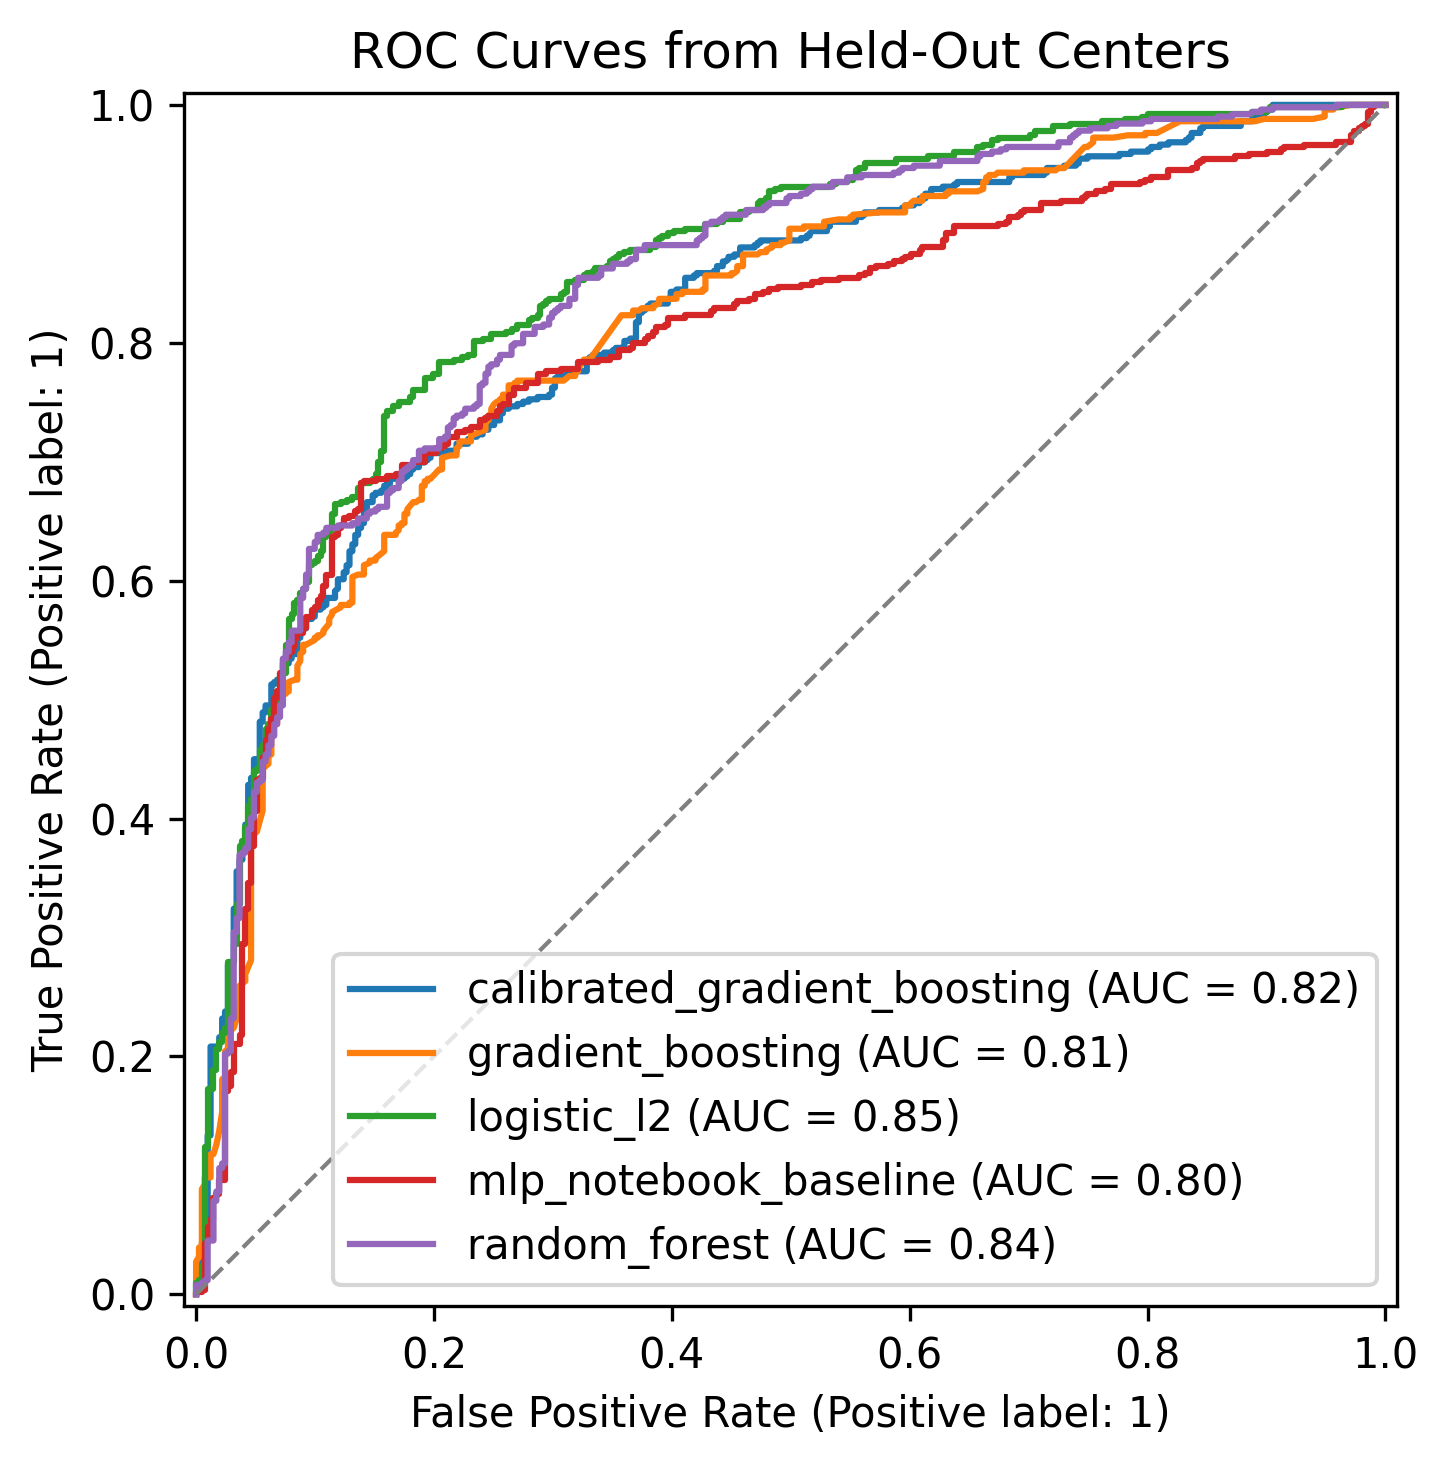

**Precision Recall Curves**

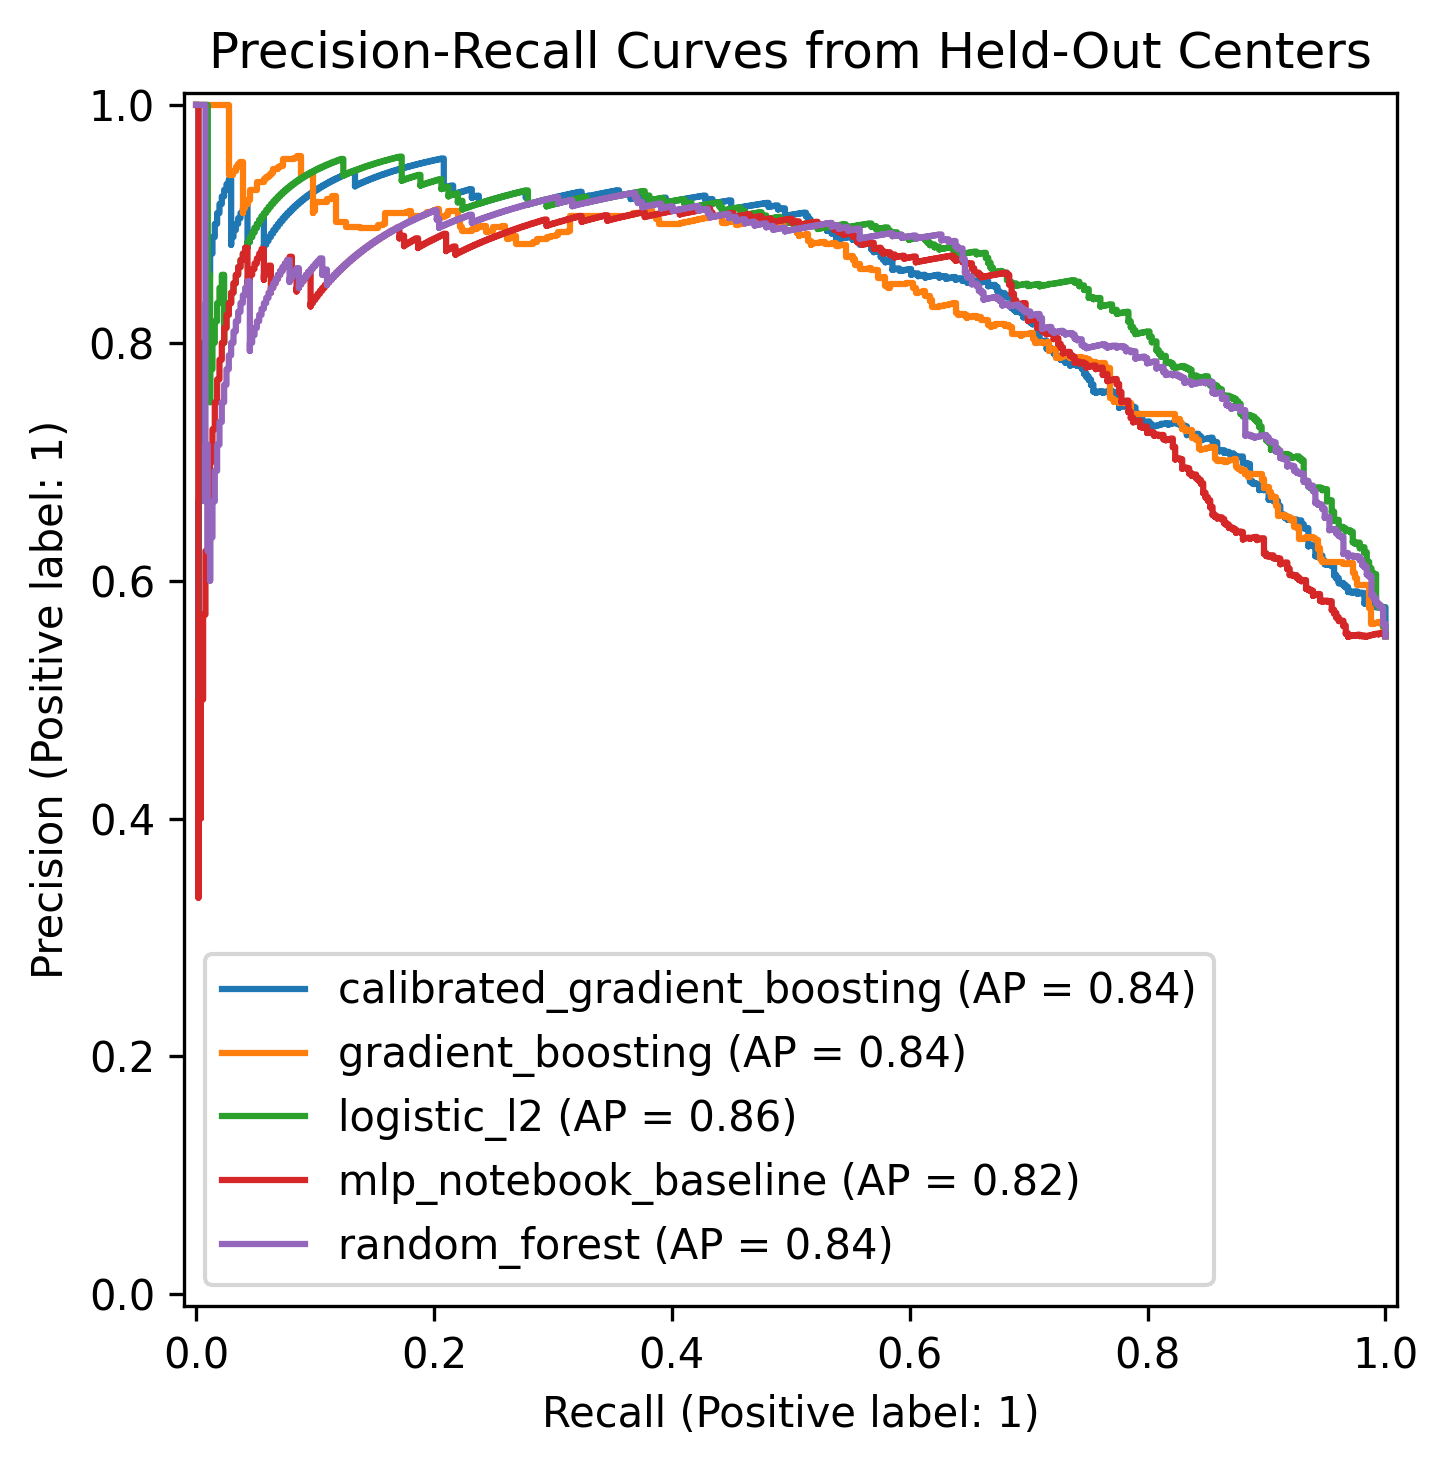

**Calibration Plots**

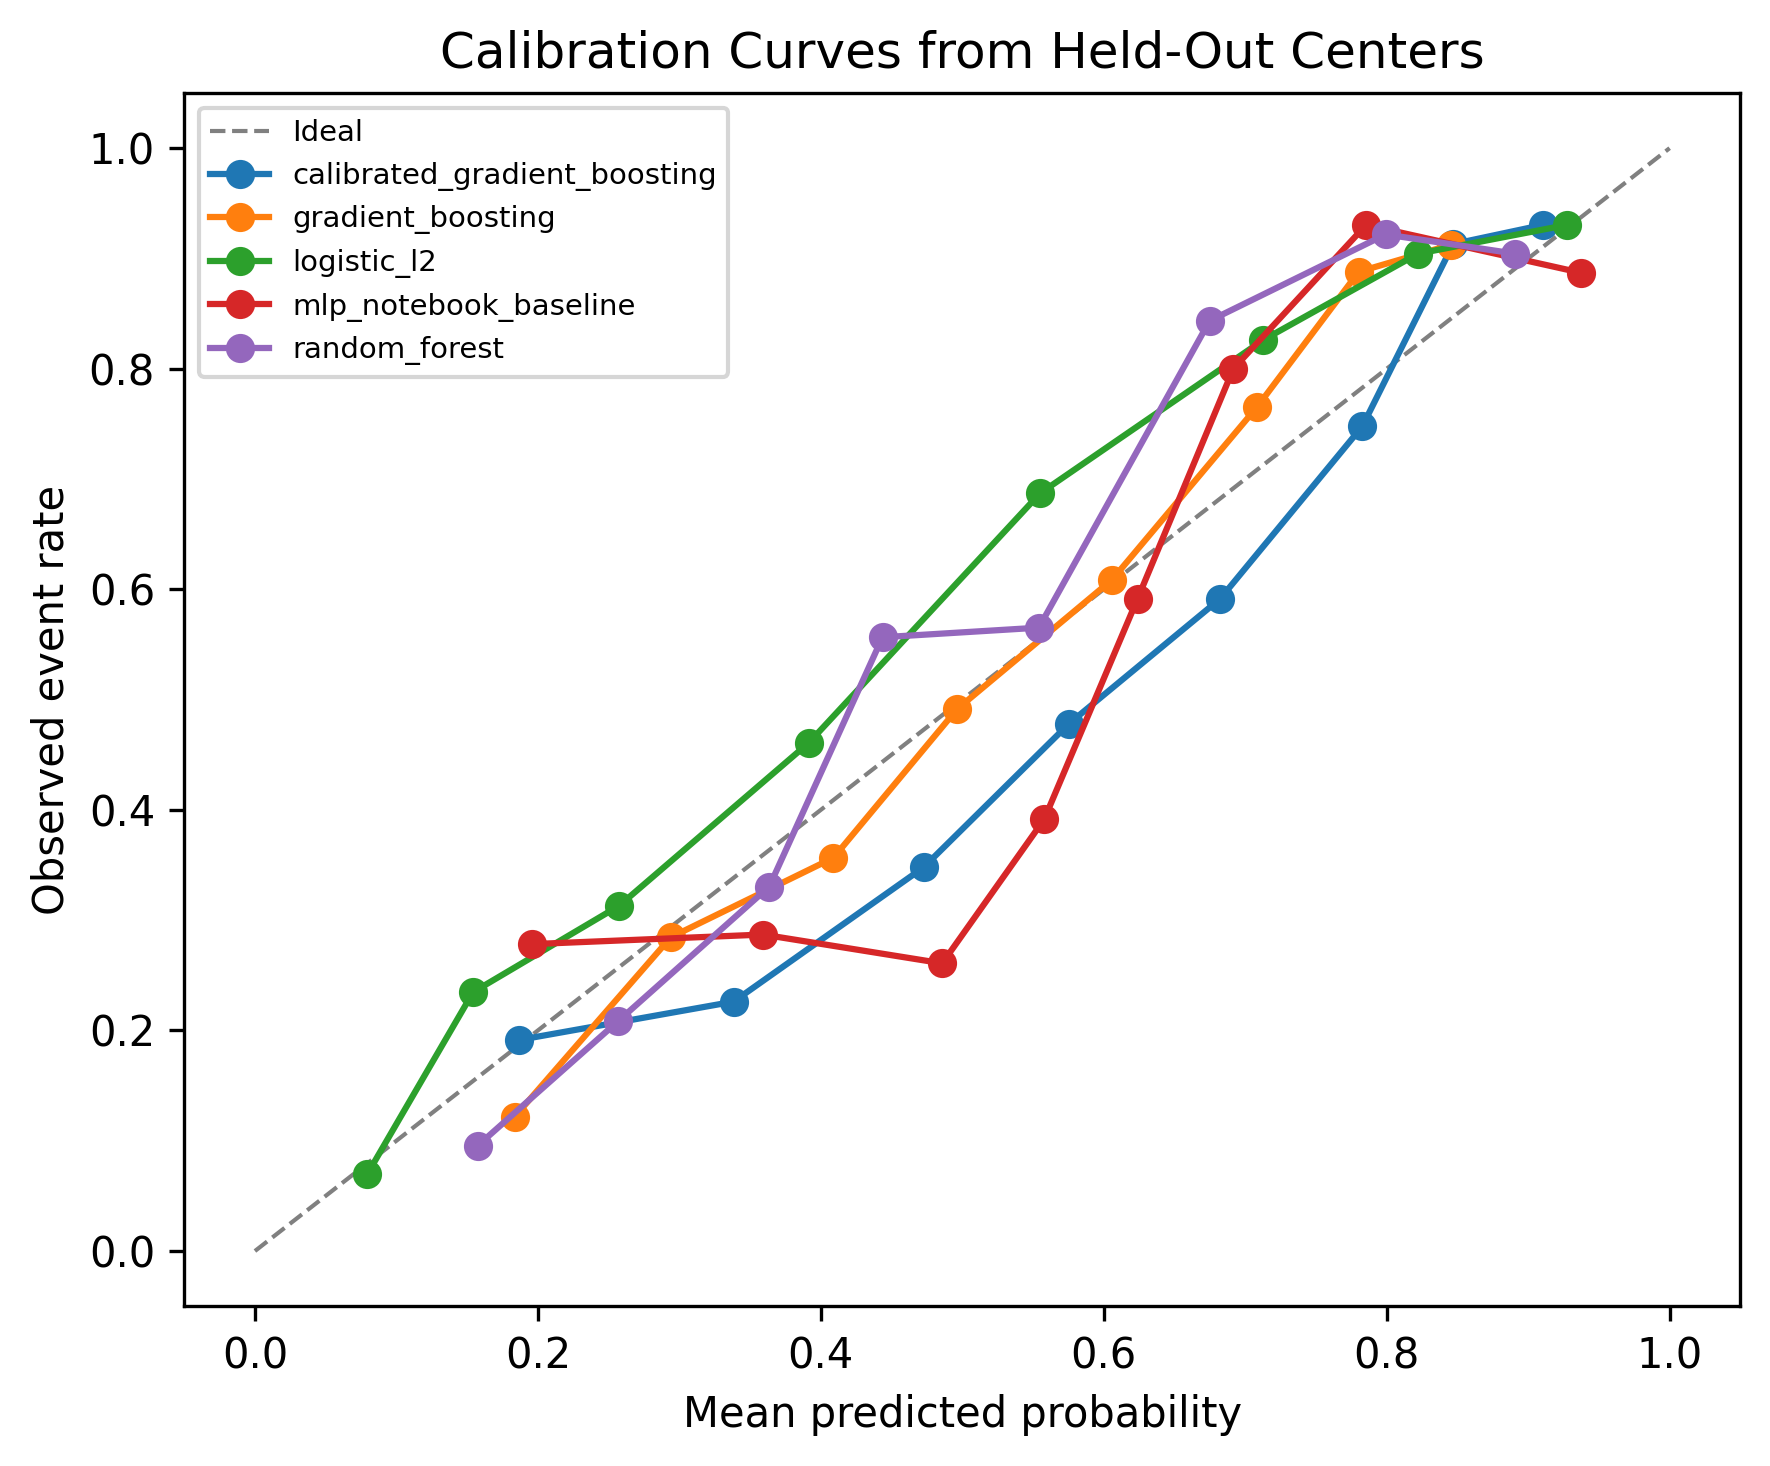

**Confusion Matrix Champion**

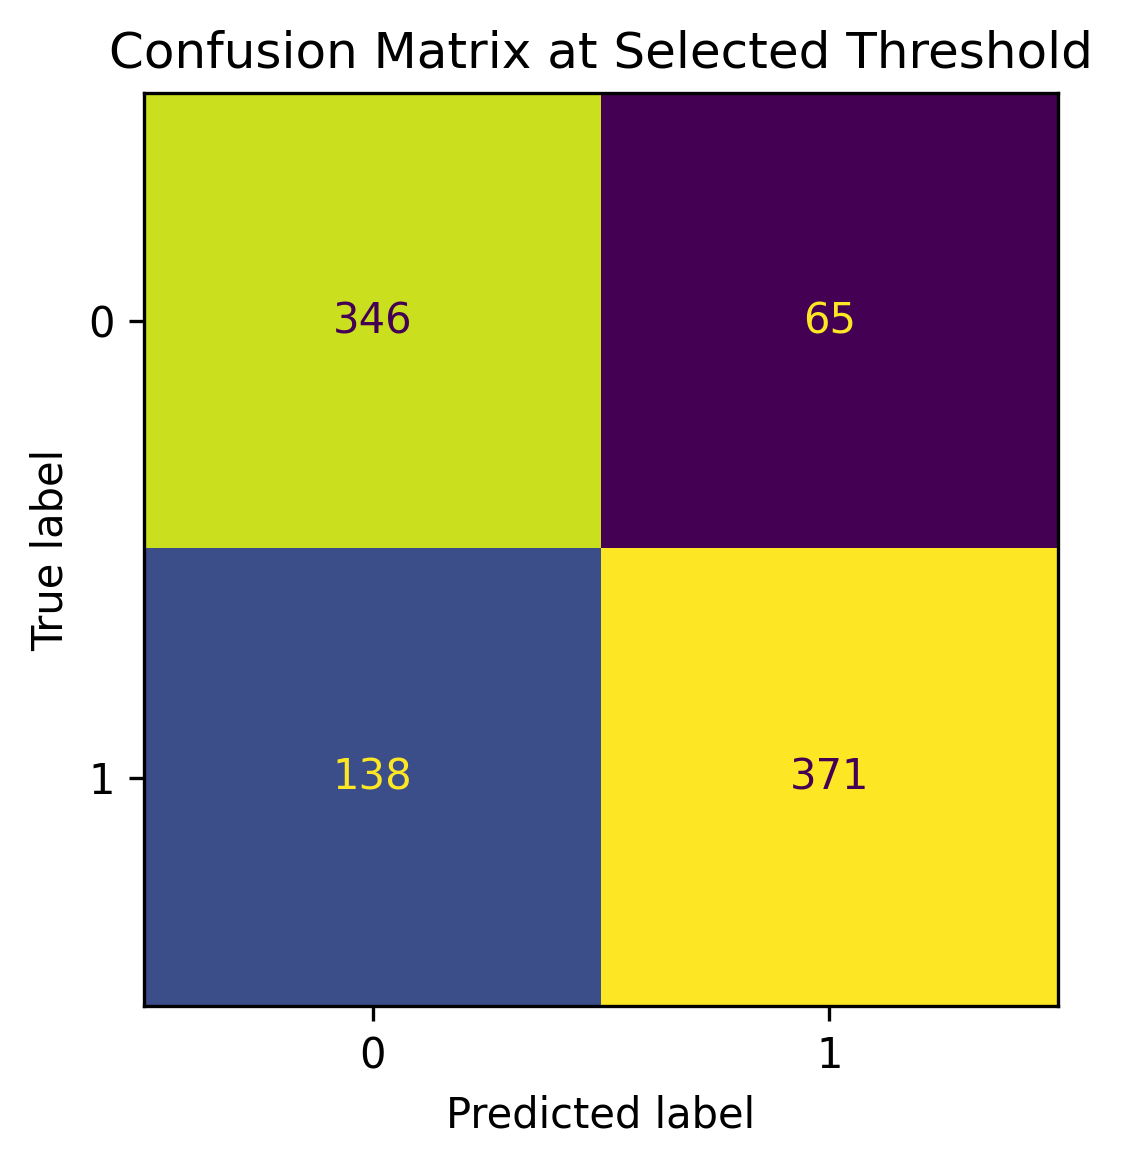

**Decision Curve**

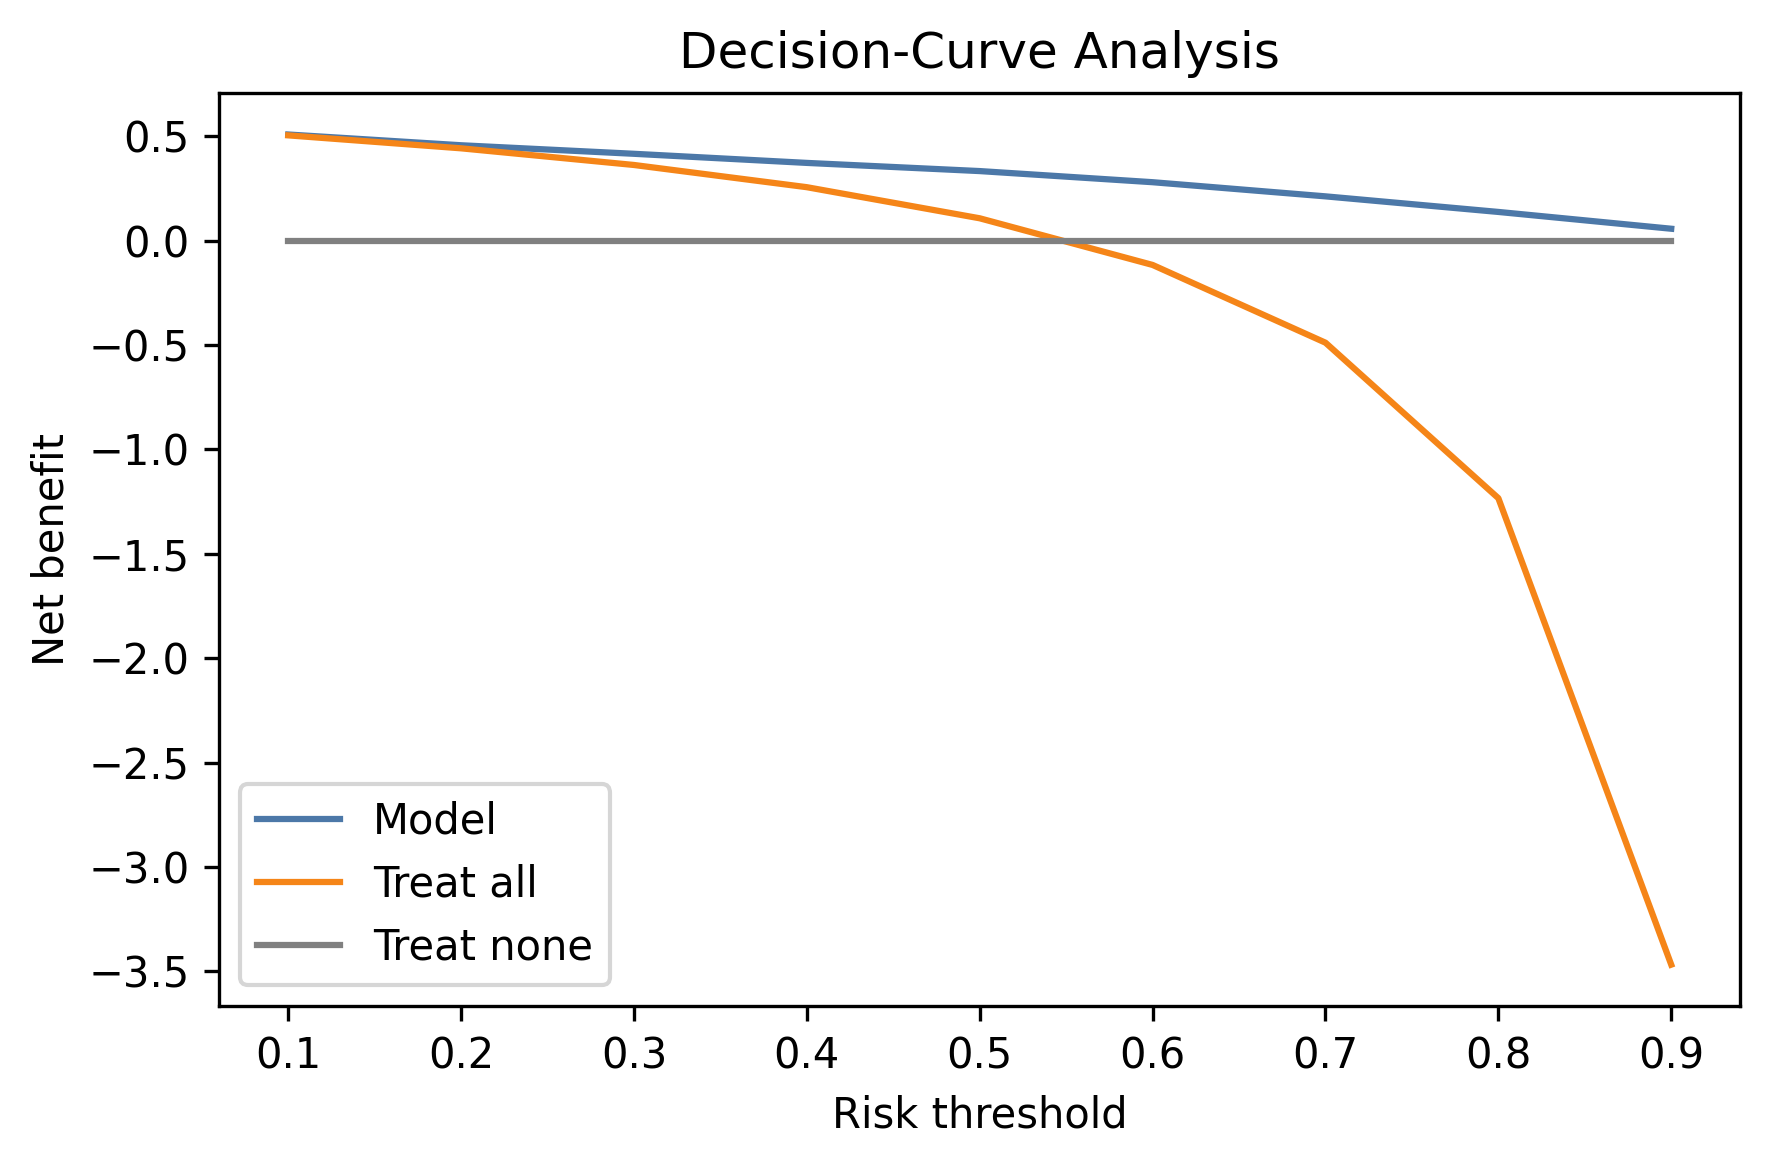

In [11]:
for figure in [
    "roc_curves.png",
    "precision_recall_curves.png",
    "calibration_plots.png",
    "confusion_matrix_champion.png",
    "decision_curve.png",
]:
    display(Markdown(f"**{figure.replace('_', ' ').replace('.png', '').title()}**"))
    display(Image(filename=str(FIG_DIR / figure)))


## Ablation / Comparative Studies

For this ML Lab project, the ablation section is presented as **comparative and sensitivity studies**.

What is included:

- Model comparison across logistic regression, random forest, gradient boosting, calibrated boosting, and MLP.
- Duplicate sensitivity on `heart.csv`, comparing duplicate-expanded and deduplicated versions.
- Threshold sensitivity from 0.10 to 0.90.
- Center-wise sensitivity by holding out each hospital/source.

This is more honest than forcing a feature-removal ablation on a small center-shifted dataset.


In [12]:
print("Supplementary duplicate sensitivity on heart.csv")
supp = tables["supplementary_heart_csv_benchmark"][[
    "dataset_version",
    "auroc_mean",
    "auprc_mean",
    "balanced_accuracy_mean",
    "brier_mean",
    "mcc_mean",
    "note",
]]
display(supp.round(3))

print("Interpretation: the duplicate-expanded file gives higher apparent performance, so it is not used for primary claims.")


Supplementary duplicate sensitivity on heart.csv


,dataset_version,auroc_mean,auprc_mean,balanced_accuracy_mean,brier_mean,mcc_mean,note
0,heart_csv_deduplicated,0.909,0.917,0.832,0.125,0.677,Supplementary only; target semantics are not p...
1,heart_csv_original_with_duplicates,0.924,0.926,0.855,0.110,0.715,Supplementary only; target semantics are not p...


Interpretation: the duplicate-expanded file gives higher apparent performance, so it is not used for primary claims.


## Explainability / XAI

The project includes explainability at two levels:

- Global explanation: which variables are most important overall.
- Local explanation: which variables moved the probability for an individual input profile.

For the final logistic regression model, local explanations are based on transformed feature contributions from the trained pipeline. These explanations are useful for transparency, but they are not causal medical explanations.


,feature,importance,signed_effect
0,cp,1.921,-0.028
1,sex,0.934,-0.028
2,exang,0.868,-0.028
3,thal,0.739,-0.028
4,slope,0.598,-0.028
5,oldpeak,0.512,0.512
6,chol,0.447,-0.447
7,fbs,0.399,-0.028
8,ca,0.353,0.353
9,thalach,0.316,-0.316


**Global Feature Importance**

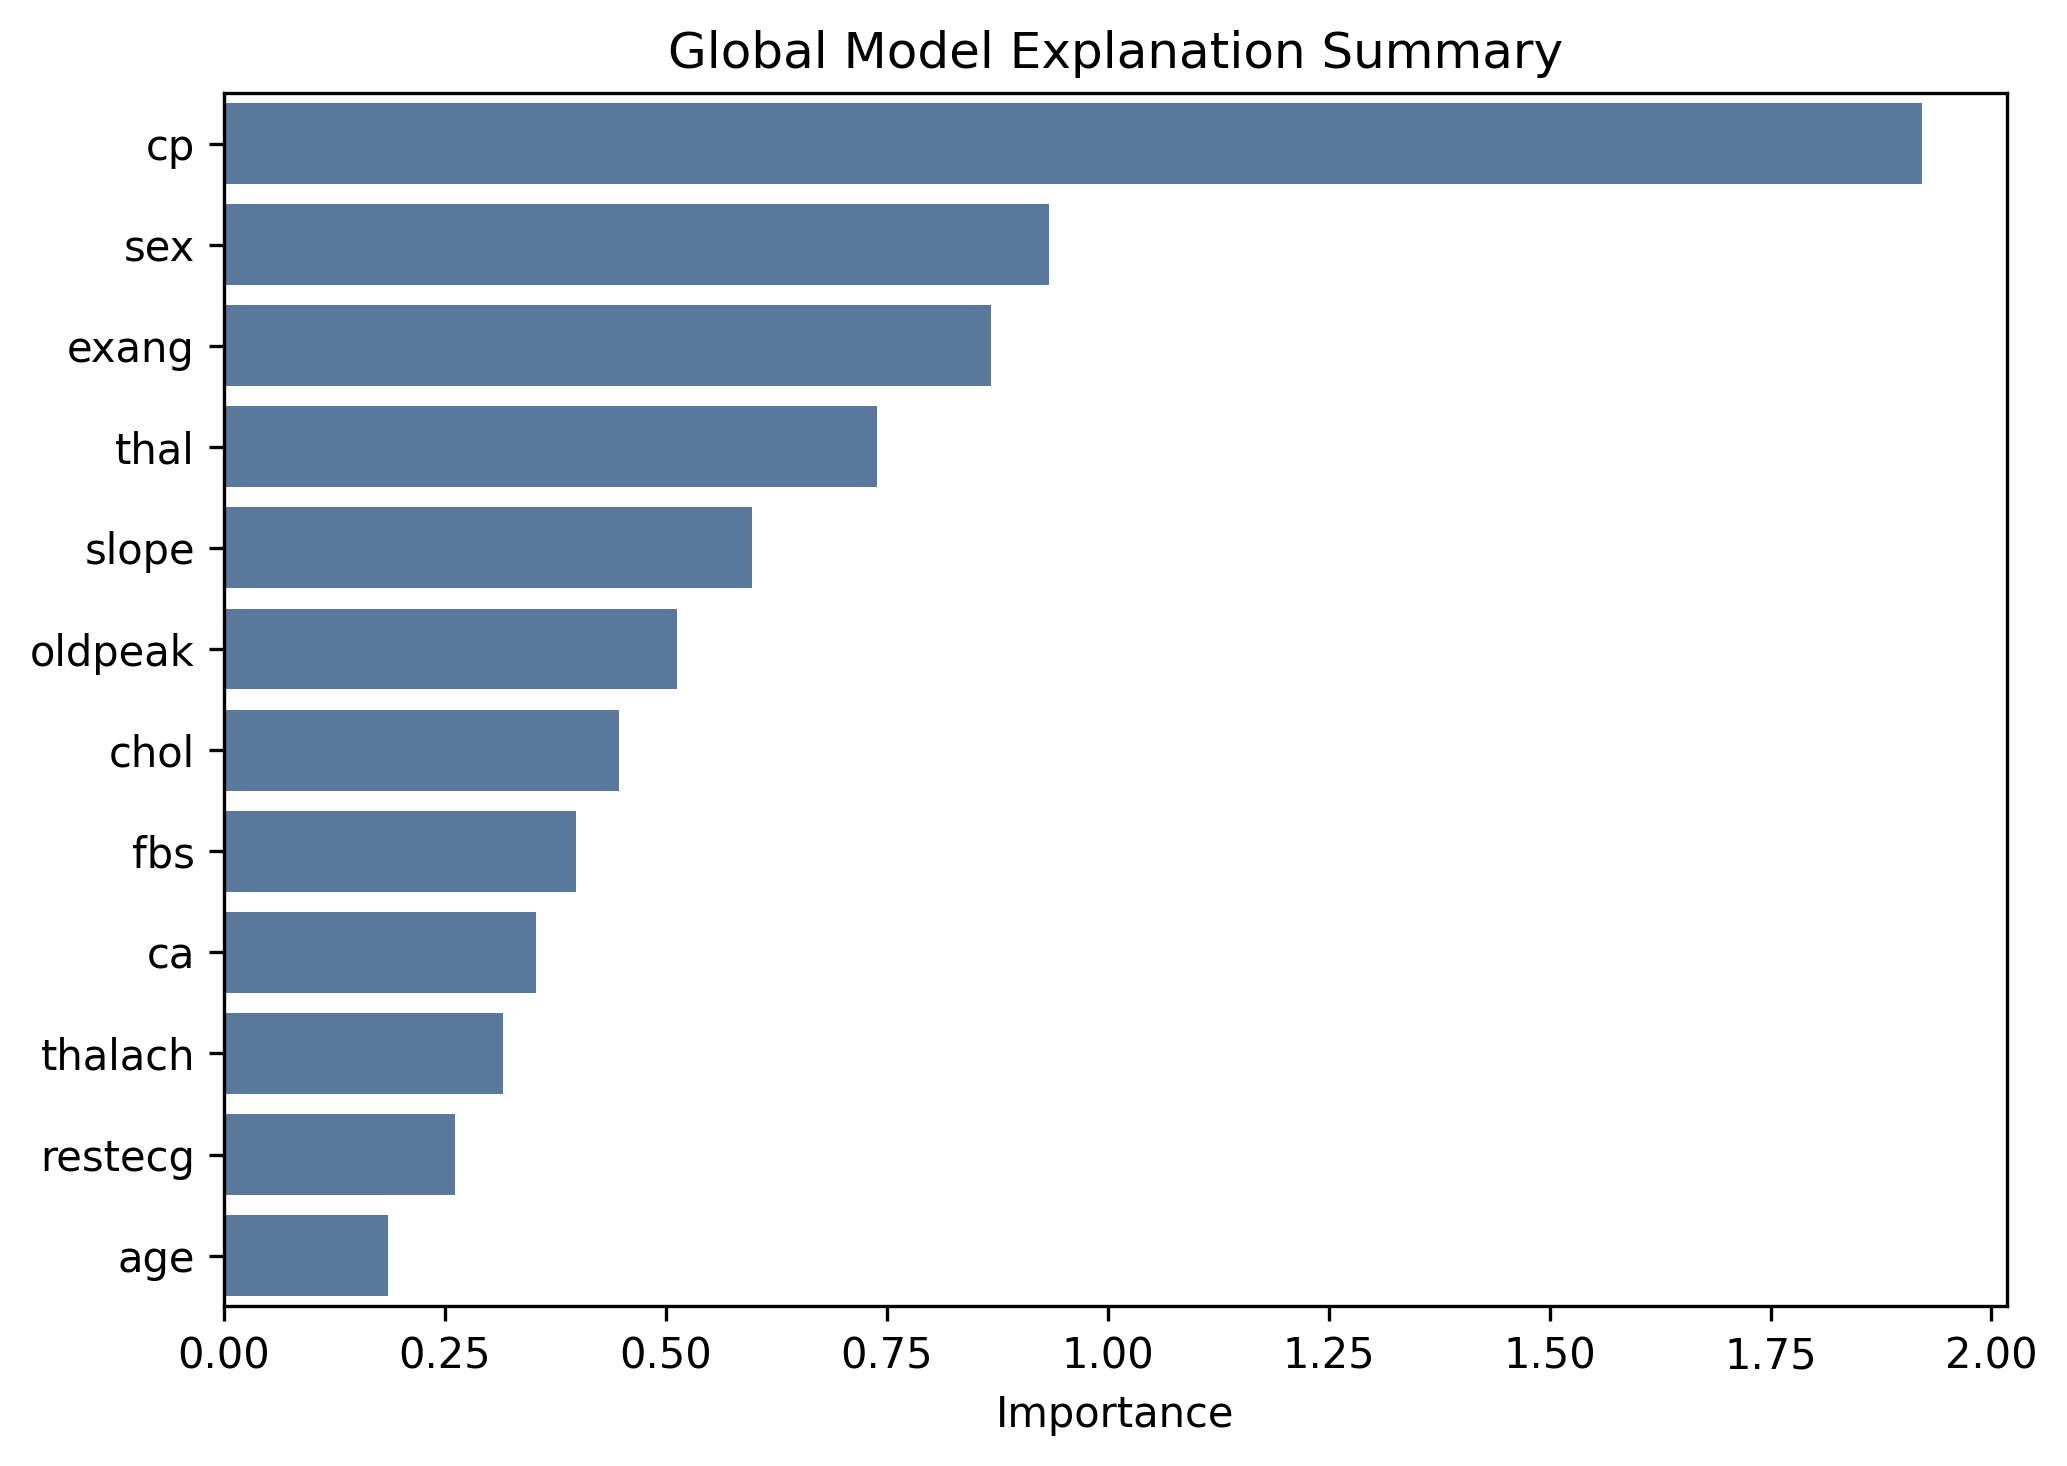

**SHAP-Style Summary**

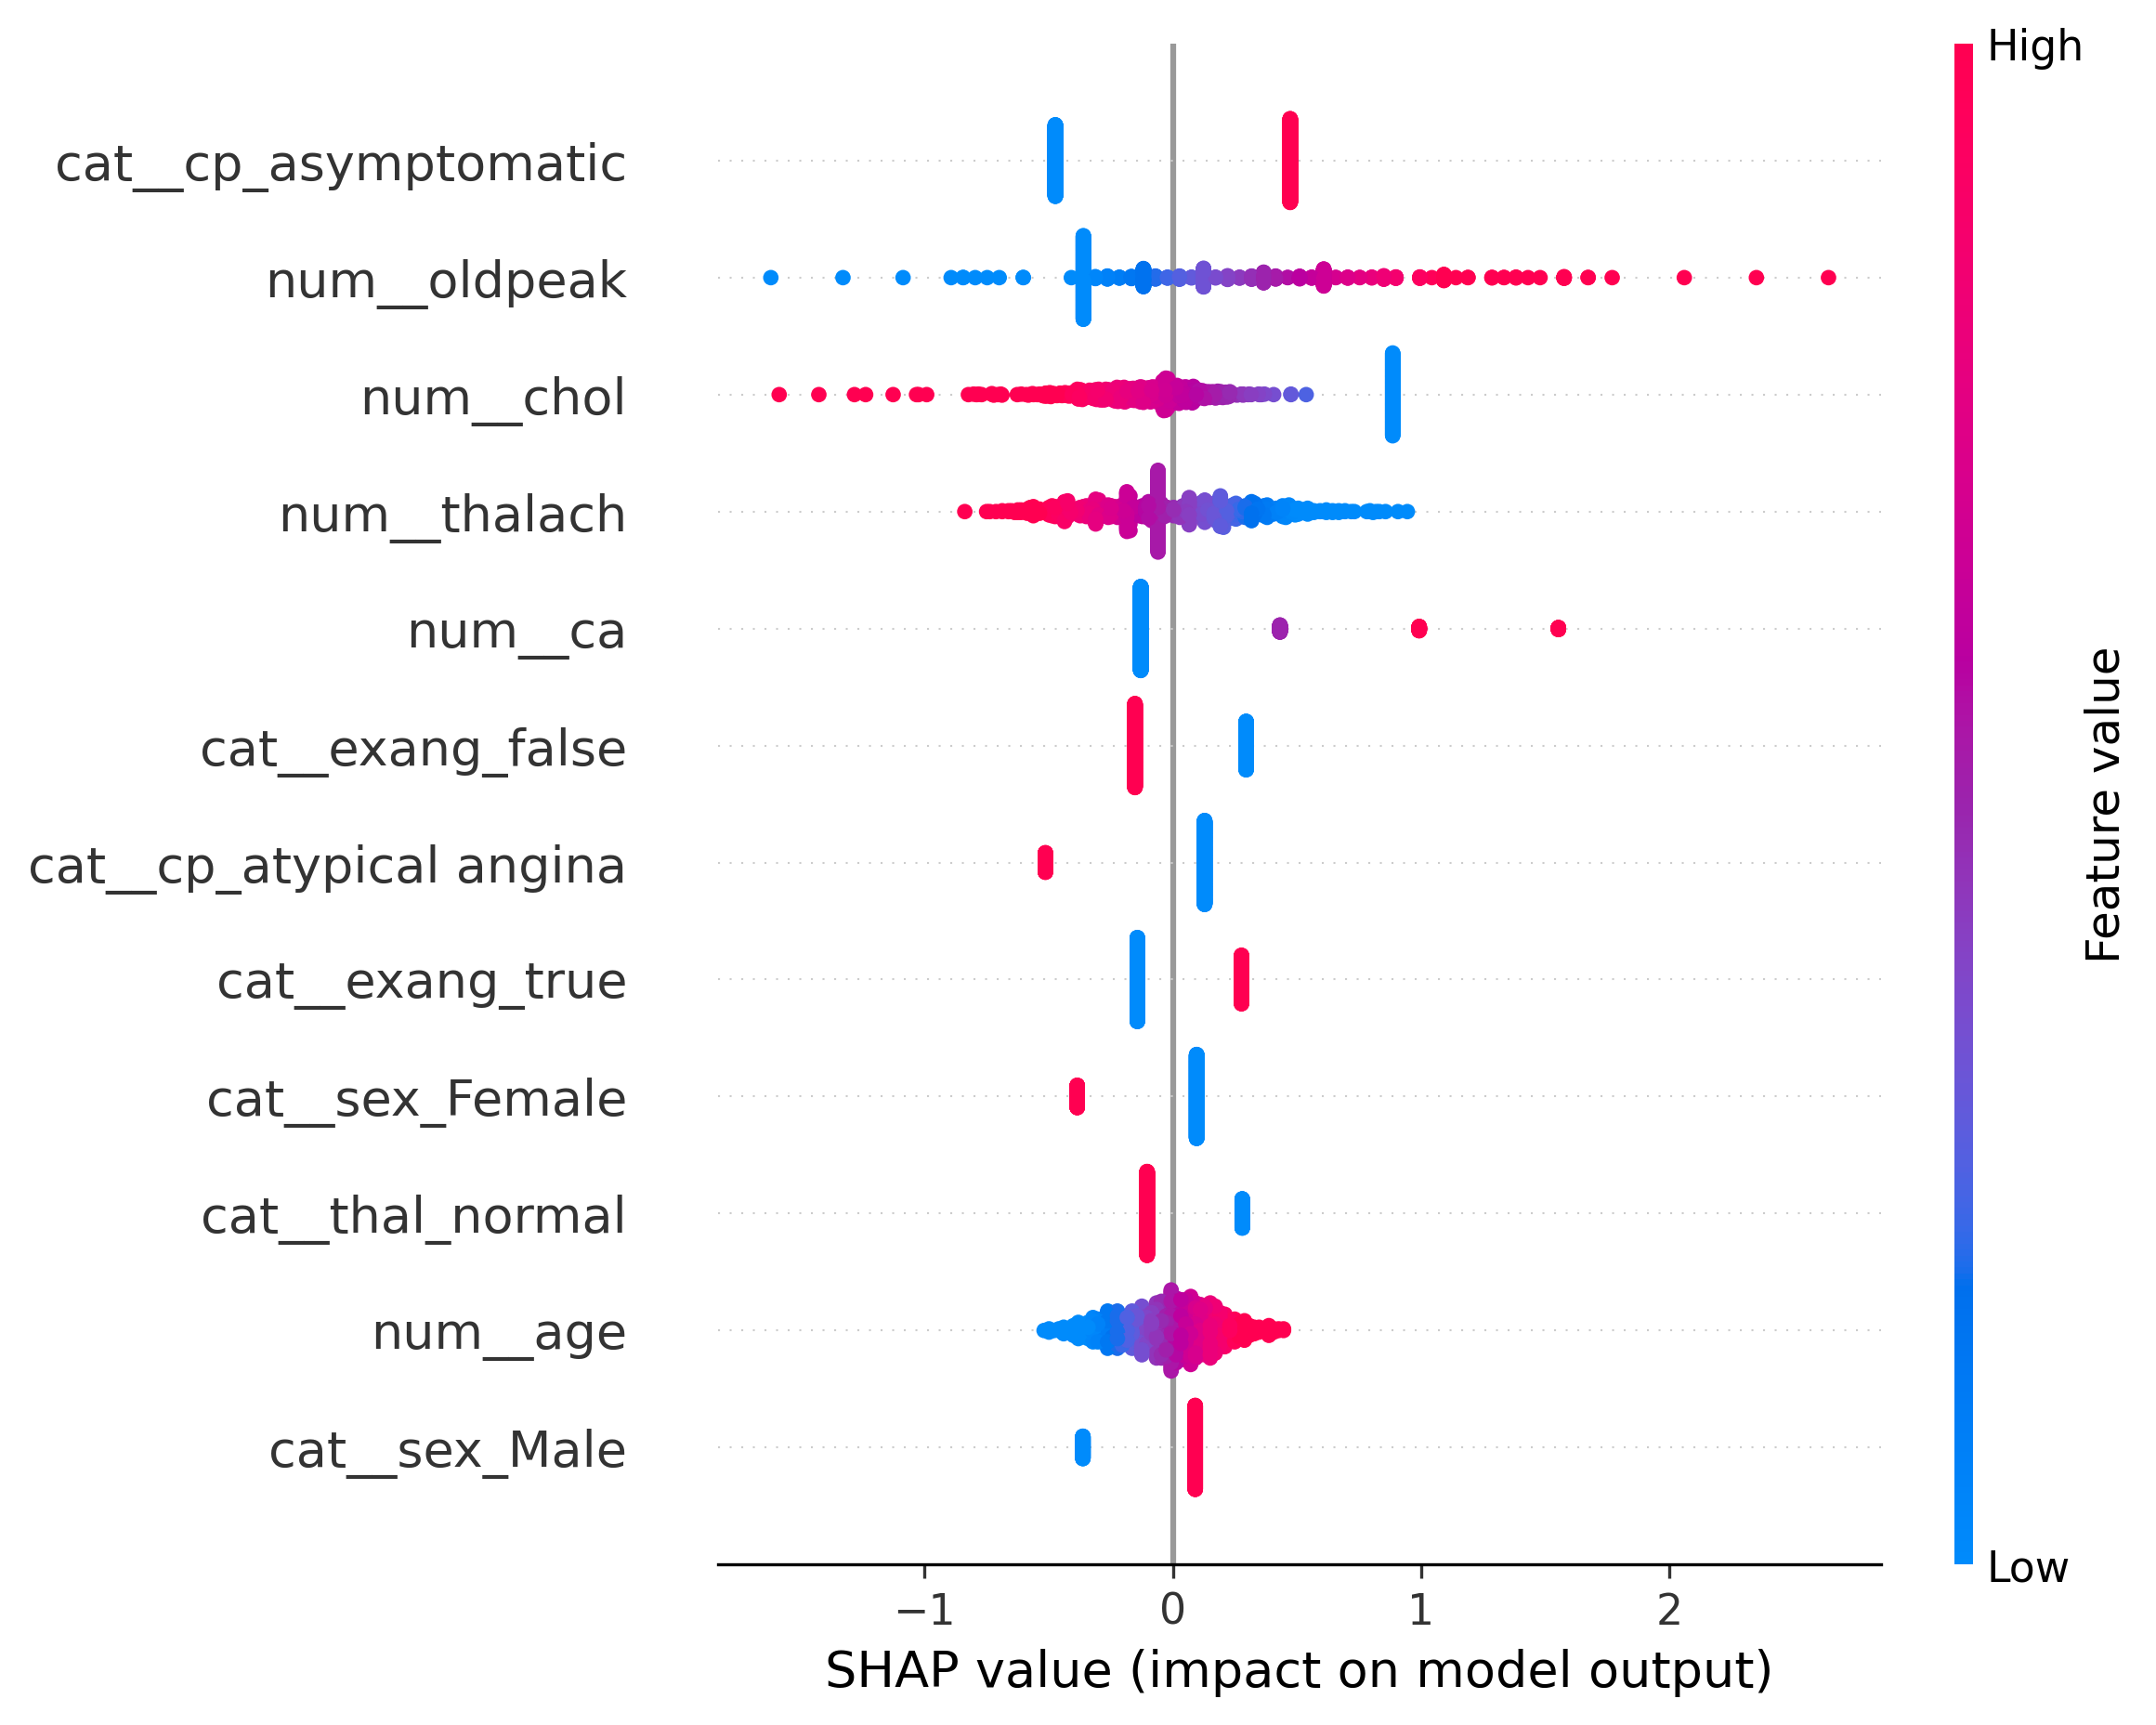

In [13]:
importance = tables["global_feature_importance"].sort_values("importance", ascending=False)
display(importance.head(12).round(3))

display(Markdown("**Global Feature Importance**"))
display(Image(filename=str(FIG_DIR / "global_feature_importance.png")))

display(Markdown("**SHAP-Style Summary**"))
display(Image(filename=str(FIG_DIR / "shap_summary.png")))


In [14]:
bundle = load_bundle(MODEL_BUNDLE)
metadata = bundle["metadata"]
print("Loaded model from bundle:", metadata["model_name"])
print("Validation design:", metadata["validation_design"])
print("Target definition:", metadata["target_definition"])

sample_patient = pd.DataFrame([
    {
        "age": 58,
        "sex": "Male",
        "cp": "asymptomatic",
        "trestbps": 140,
        "chol": 250,
        "fbs": "false",
        "restecg": "normal",
        "thalach": 135,
        "exang": "true",
        "oldpeak": 2.1,
        "slope": "flat",
        "ca": 1,
        "thal": "reversable defect",
    }
])

probability = float(bundle["model"].predict_proba(sample_patient)[0, 1])
explanation = local_explanation(bundle, sample_patient, top_n=6)

sample_display = sample_patient.T.rename(columns={0: "value"})
display(Markdown("**Example Patient Input**"))
display(sample_display)

display(Markdown(f"**Predicted probability:** {probability:.1%}"))
display(Markdown(f"**Risk category:** {risk_category(probability)}"))
display(Markdown(risk_message(probability)))

display(Markdown("**Why the model predicted this risk**"))
display(pd.DataFrame(explanation))


Loaded model from bundle: logistic_l2
Validation design: leave-one-center-out internal-external cross-validation
Target definition: target_binary = 1 if UCI num > 0 else 0


**Example Patient Input**

,value
age,58
sex,Male
cp,asymptomatic
trestbps,140
chol,250
fbs,false
restecg,normal
thalach,135
exang,true
oldpeak,2.1


**Predicted probability:** 95.5%

**Risk category:** elevated

The model estimates an elevated probability of recorded heart disease for this benchmark profile.

**Why the model predicted this risk**

,feature,value,direction,contribution,clinical_note
0,cp,asymptomatic,increased the estimated probability,0.9463,Chest pain category is influential because sym...
1,oldpeak,2.1,increased the estimated probability,0.6038,Higher exercise-induced ST depression commonly...
2,sex,Male,increased the estimated probability,0.4528,This feature contributed to the model estimate...
3,ca,1,increased the estimated probability,0.4335,A larger number of major vessels can increase ...
4,exang,true,increased the estimated probability,0.4196,Exercise-induced angina commonly increases mod...
5,slope,flat,increased the estimated probability,0.2847,Flat or downsloping ST segment patterns often ...


## Localhost Application

The project includes a FastAPI localhost app with one public prediction workflow. The frontend contains a clinical-style input form, predicted probability, calibrated risk category, explanation panel, model metadata, API documentation link, and a research-prototype disclaimer.

Run on Windows:

```powershell
run_app.bat
```

Then open:

```text
http://127.0.0.1:8000
```

API documentation is available at:

```text
http://127.0.0.1:8000/docs
```

The app uses the same serialized model bundle loaded above, so the notebook and web app are connected to the same trained artifact.


In [15]:
project_inventory = []
for relative_path, description in [
    ("src/domain", "Feature definitions, target names, risk-category rules"),
    ("src/application", "Training, evaluation, and reporting use cases"),
    ("src/infrastructure", "Config, CSV loading, persistence, tracking"),
    ("src/models", "Candidate model factory"),
    ("src/evaluation", "Metrics, calibration, decision curves, explanations"),
    ("src/api", "FastAPI routes and schemas"),
    ("src/webapp", "Frontend templates and static files"),
    ("docs", "Current work, data, and leakage audit documents"),
    ("reports/figures", "Generated publication-style figures"),
    ("reports/tables", "Generated experiment tables"),
    ("reports/manuscript", "IEEE-style project paper files"),
    ("tests", "Unit, integration, and API tests"),
    ("docker", "Docker deployment files"),
    (".github/workflows", "GitHub Actions CI"),
]:
    path = PROJECT_ROOT / relative_path
    project_inventory.append(
        {
            "path": relative_path,
            "exists": path.exists(),
            "items": len(list(path.rglob("*"))) if path.exists() else 0,
            "purpose": description,
        }
    )

display(pd.DataFrame(project_inventory))


,path,exists,items,purpose
0,src/domain,True,7,"Feature definitions, target names, risk-catego..."
1,src/application,True,3,"Training, evaluation, and reporting use cases"
2,src/infrastructure,True,12,"Config, CSV loading, persistence, tracking"
3,src/models,True,2,Candidate model factory
4,src/evaluation,True,9,"Metrics, calibration, decision curves, explana..."
5,src/api,True,7,FastAPI routes and schemas
6,src/webapp,True,4,Frontend templates and static files
7,docs,True,3,"Current work, data, and leakage audit documents"
8,reports/figures,True,11,Generated publication-style figures
9,reports/tables,True,17,Generated experiment tables


## Project Explanation

The project started from an exploratory neural-network notebook for heart disease prediction. I first audited the notebook and datasets, then rebuilt the work as a reproducible ML project. The primary dataset is the UCI-style heart disease file because it includes hospital/source information, allowing leave-one-center-out validation. The pipeline standardizes the schema, defines a binary target, keeps imputation and encoding inside cross-validation folds, compares classical ML models and an MLP baseline, and selects the final model using calibration, discrimination, stability, and interpretability. Logistic regression was selected because it was more stable and interpretable than the neural-network baseline for this small dataset. The final model is saved as a bundle and served through a FastAPI localhost app with probability, risk category, and explanation output.


## Conclusion and Future Work

This project meets the ML Lab requirements by combining a runnable notebook, a clean codebase, generated reports, comparative studies, explainability, and a localhost app. It is stronger than the exploratory notebook because it avoids duplicate leakage, avoids test-set tuning, uses center-aware validation, reports calibration and threshold behavior, and keeps model claims honest.

Future work should include larger modern cohorts, prospective validation, fairness analysis, more robust missingness modeling, and clinician-centered usability testing. Until that is done, the system should be presented only as an educational and research prototype.


## References

1. Collins GS et al. TRIPOD+AI statement: updated guidance for reporting clinical prediction models that use regression or machine learning methods. BMJ, 2024.
2. Collins GS et al. PROBAST+AI: an updated quality, risk of bias, and applicability assessment tool for prediction models using regression or artificial intelligence methods. BMJ, 2025.
3. Detrano R et al. International application of a new probability algorithm for the diagnosis of coronary artery disease. American Journal of Cardiology, 1989.
4. Pedregosa F et al. Scikit-learn: Machine Learning in Python. Journal of Machine Learning Research, 2011.
5. Lundberg SM and Lee SI. A Unified Approach to Interpreting Model Predictions. NeurIPS, 2017.
